# ATP Tennis Match Prediction (2000-2024)
---
---

## 1. Introduzione e Obiettivi

L'obiettivo di questo progetto è sviluppare un modello di Machine Learning basato due modelli di allenamento in grado di predire il vincitore di una partita di tennis professionistico ATP.
Il tennis è uno sport caratterizzato da una forte componente stocastica, ma anche da pattern storici ben definiti come gerarchie di ranking, punteggio di ELO, adattamento alle superfici, scontri diretti.

I dati utilizzati provengono dal repository pubblico di Jeff Sackmann (https://github.com/JeffSackmann/tennis_atp/tree/master). Il dataset completo copre l'arco temporale 1968-2024. Per questo progetto abbiamo scelto di iniziare dall'anno 2000 per garantire una maggiore consistenza nella raccolta statistica (es. minuti giocati, ace, doppi falli) che negli anni precedenti era spesso frammentaria.

---
---

## 2. Data Ingestion & Merging
I dati grezzi sono suddivisi in file CSV annuali (un file per anno). Il primo passo della pipeline è l'aggregazione di questi file in un unico DataFrame Pandas cronologicamente ordinato.
Durante la fase di ingestionrecupero dei dati, abbiamo applicato i seguenti filtri per garantire una qualità alta del dato:
- Esclusione dei tornei "Futures": I dati relativi ai tornei minori (Futures) sono stati esclusi. Questi match presentano spesso statistiche incomplete o inaffidabili e introducono un elevato livello di rumore che potrebbe confondere il modello.
- Esclusione delle Qualificazioni: Sono stati considerati solo i match dei tabelloni principali del circuito ATP e Challenger.
- Parsing delle Date: La colonna tourney_date è stata convertita immediatamente in formato datetime per permettere il futuro split cronologico per il Training e il Testing evitando il Data Leakage temporale.

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from collections import deque

In [2]:
INPUT_FOLDER = "datasets"
OUTPUT_FILENAME = "datasets_produced\\atp_matches_2000_2024_raw.csv"

print("--- UNIONE DATI ---")
    
    # Cerca file che iniziano con "atp_matches_" dentro la cartella datasets
pattern = os.path.join(INPUT_FOLDER, "atp_matches_*.csv")
all_files = glob.glob(pattern)
    

li = []
for filename in all_files:
    try:
        df_temp = pd.read_csv(filename, index_col=None, header=0)
            
        # Convertiamo subito la data (formato YYYYMMDD) in oggetto datetime
        df_temp['tourney_date'] = pd.to_datetime(df_temp['tourney_date'], format='%Y%m%d', errors='coerce')
            
        li.append(df_temp)
    except Exception as e:
        print(f"Errore caricamento {filename}: {e}")

if not li:
    print("Errore: Nessun file caricato.")
    
print("--- UNIONE COMPLETATA ---")

--- UNIONE DATI ---
--- UNIONE COMPLETATA ---


In [3]:
# Unione
df_total = pd.concat(li, axis=0, ignore_index=True)

# Ordinamento CRONOLOGICO (Fondamentale per l'ELO, anche se dovrebbero già essere ordinati)
df_total = df_total.sort_values(by=['tourney_date', 'tourney_id', 'match_num']).reset_index(drop=True)

#Salvo il dataset intero
df_total.to_csv(OUTPUT_FILENAME, index=False)
print(f"--- COMPLETATO ---")
print(f"File unito salvato come: {OUTPUT_FILENAME}")
print(f"Totale partite: {len(df_total)}")
print(df_total[['tourney_date', 'winner_name', 'loser_name']].head())

df_total.head()

--- COMPLETATO ---
File unito salvato come: datasets_produced\atp_matches_2000_2024_raw.csv
Totale partite: 74906
  tourney_date          winner_name        loser_name
0   2000-01-03       Thomas Enqvist    Arnaud Clement
1   2000-01-03        Roger Federer  Jens Knippschild
2   2000-01-03  Jan Michael Gambill     Wayne Arthurs
3   2000-01-03   Sebastien Grosjean       Andrew Ilie
4   2000-01-03        Magnus Norman      Scott Draper


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2000-339,Adelaide,Hard,32,A,2000-01-03,1,102358,1.0,NaN,...,37.0,25.0,13.0,9.0,2.0,4.0,4.0,2606.0,56.0,805.0
1,2000-339,Adelaide,Hard,32,A,2000-01-03,2,103819,NaN,NaN,...,15.0,13.0,12.0,8.0,0.0,3.0,64.0,749.0,91.0,525.0
2,2000-339,Adelaide,Hard,32,A,2000-01-03,3,102998,NaN,NaN,...,59.0,49.0,22.0,16.0,4.0,5.0,58.0,803.0,105.0,449.0
3,2000-339,Adelaide,Hard,32,A,2000-01-03,4,103206,7.0,NaN,...,22.0,12.0,8.0,8.0,1.0,6.0,27.0,1298.0,54.0,845.0
4,2000-339,Adelaide,Hard,32,A,2000-01-03,5,102796,3.0,NaN,...,40.0,25.0,16.0,10.0,7.0,10.0,15.0,1748.0,154.0,297.0


---
---

## 3. Data Cleaning e Strategie di Imputazione

In [4]:
INPUT_FILE = "datasets_produced\\atp_matches_2000_2024_raw.csv"
OUTPUT_FILE = "datasets_produced\\atp_matches_2000_2024_cleaned.csv"

def clean_data(df):
    print(f"Righe originali: {len(df)}")
    
    # 1. GESTIONE TESTE DI SERIE (SEED)
    # Se vuoto, non è testa di serie,quindi mettiamo un valore alto (es. 100, signifia che è il 100esimo favorito alla vittoria del torneo)
    # così il modello capisce che vale meno della testa di serie n. 32
    df['winner_seed'] = df['winner_seed'].fillna(100)
    df['loser_seed'] = df['loser_seed'].fillna(100)
    
    # 2. GESTIONE ENTRY (WC, Q, etc.)
    # Se vuoto, è un ingresso Standard ('STD')
    df['winner_entry'] = df['winner_entry'].fillna('STD')
    df['loser_entry'] = df['loser_entry'].fillna('STD')
    
    # 3. GESTIONE RANKING
    # Se vuoto, assumiamo sia un ranking basso (es. 2000) non dovrebbero esserci player con rank o punti vuoti
    df['winner_rank'] = df['winner_rank'].fillna(2000)
    df['loser_rank'] = df['loser_rank'].fillna(2000)
    df['winner_rank_points'] = df['winner_rank_points'].fillna(0)
    df['loser_rank_points'] = df['loser_rank_points'].fillna(0)
    
    # 4. GESTIONE DATI FISICI (Altezza, Età) -> MEDIA
    # Calcoliamo la media globale per riempire gli attributi vuoti
    avg_age_w = df['winner_age'].mean()
    avg_age_l = df['loser_age'].mean()
    avg_ht_w = df['winner_ht'].mean()
    avg_ht_l = df['loser_ht'].mean()
    
    df['winner_age'] = df['winner_age'].fillna(avg_age_w)
    df['loser_age'] = df['loser_age'].fillna(avg_age_l)
    df['winner_ht'] = df['winner_ht'].fillna(avg_ht_w)
    df['loser_ht'] = df['loser_ht'].fillna(avg_ht_l)
    
    # Gestione mano (Destra/Sinistra), visto che la maggior parte è destra, riempiamo con 'R'
    df['winner_hand'] = df['winner_hand'].fillna('R')
    df['loser_hand'] = df['loser_hand'].fillna('R')
    
    # 5. GESTIONE SURFACE (Superficie)
    # Se mancano poche righe, meglio rimuoverle (non dovrebbe essere un dato mancante)
    df = df.dropna(subset=['surface']).copy()
    
    # 6. GESTIONE STATISTICHE MATCH (Ace, DF, Minuti...)
    # Riempiamo con -1 perchè questi dati non saranno input diretto (non posso sapere a priori le statistiche di un match futuro)
    # ma se calcoliamo le medie storiche dobbiamo ricordarci di toglierli controllare solo i valori >=0
    # Per 'minutes' usiamo la media di tutte le partite
    stats_cols = [
        'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 
        'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 
        'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced'
    ]
    
    for col in stats_cols:
        # Se è 'minutes' usiamo la media, per gli altri (conteggi) usiamo 0
        if col == 'minutes':
            df[col] = df[col].fillna(df[col].mean())
        else:
            df[col] = df[col].fillna(-1)
            
    print(f"Righe dopo pulizia: {len(df)}")
    
    # Verifica finale
    missing = df.isnull().sum().sum()
    print(f"Valori mancanti residui: {missing}")
    
    return df

print("--- INIZIO PULIZIA DATI ---")
try:
    df = pd.read_csv(INPUT_FILE)
except FileNotFoundError:
    print(f"File {INPUT_FILE} non trovato!")

df_clean = clean_data(df)
    
df_clean.to_csv(OUTPUT_FILE, index=False)
print(f"Dataset pulito salvato come: {OUTPUT_FILE}")

--- INIZIO PULIZIA DATI ---
Righe originali: 74906
Righe dopo pulizia: 74853
Valori mancanti residui: 0
Dataset pulito salvato come: datasets_produced\atp_matches_2000_2024_cleaned.csv


In [5]:
INPUT_FILE_MATCHES = "datasets_produced\\atp_matches_2000_2024_cleaned.csv"
INPUT_FILE_RANK_90 = "datasets\\atp_rankings_90s.csv" 
OUTPUT_FILE_ML = "datasets_produced\\dataset_ml_ready.csv"
OUTPUT_FILE_READABLE = "datasets_produced\\dataset_enriched.csv"

---
---
## 4. Feature Engineering

#### 4.1. Funzioni di supporto: Caricamento Ranking Iniziale

In [6]:
def load_initial_rankings(rank_file):
    print(f"--- Caricamento Ranking Iniziale da {rank_file} ---")
    try:
        df_rank = pd.read_csv(rank_file)
        last_date = df_rank['ranking_date'].max()
        df_init = df_rank[df_rank['ranking_date'] == last_date].copy()
        
        initial_elo_dict = {}
        initial_matches_dict = {}
        
        for _, row in df_init.iterrows():
            pid = row['player']
            rank = row['rank']
            if rank < 1: rank = 1
            elo_val = 2500 - 300 * np.log10(rank)
            if elo_val < 1400: elo_val = 1400
            initial_elo_dict[pid] = elo_val
            
            if rank <= 10: est_matches = 500
            elif rank <= 50: est_matches = 300
            elif rank <= 100: est_matches = 150
            elif rank <= 500: est_matches = 50
            else: est_matches = 10  
            initial_matches_dict[pid] = est_matches
            
        print(f"Inizializzati {len(initial_elo_dict)} giocatori.") 
        return initial_elo_dict, initial_matches_dict
    except Exception as e:
        print(f"ATTENZIONE: Impossibile caricare ranking ({e}).")
        return {}, {}

---
#### 4.1. Funzioni di supporto: Calcolo K-factor

In [7]:
def get_k_factor(matches_count, tourney_level):
    if matches_count < 30:
        k_base = 50  
    elif matches_count < 100:
        k_base = 40  
    else:
        k_base = 32   #(Standard scacchistico)
        
    if tourney_level == 'G': multiplier = 1.1
    elif tourney_level == 'M' or tourney_level == 'F': multiplier = 1.05
    else: multiplier = 1.0
    
    return k_base * multiplier

---
#### 4.3. Simulazione Storica (con Matematica dell'ELO integrata)

In [8]:
def calculate_features(df, initial_elos, initial_matches):
    print("Calcolo ELO, H2H e Feature Avanzate")
    
    '''
    FASE 1: INIZIALIZZAZZIONE E MEMORIA
    '''
    elo_overall = initial_elos.copy()
    elo_surface = {'Hard': initial_elos.copy(), 'Clay': initial_elos.copy(), 
                   'Grass': initial_elos.copy(), 'Carpet': initial_elos.copy()}
    matches_played = initial_matches.copy()
    h2h_history = {} 

   
    win_history = {} 
    elo_history = {} 

    feats = {
        'w_elo': [], 'l_elo': [], 'w_surface_elo': [], 'l_surface_elo': [],
        'w_h2h': [], 'l_h2h': [], 'w_prob_elo': [],
        'w_win_last_5': [], 'l_win_last_5': [],
        'w_win_last_25': [], 'l_win_last_25': [],
        'w_win_last_50': [], 'l_win_last_50': [],
        'w_win_last_100': [], 'l_win_last_100': [],
        'w_elo_grad_20': [], 'l_elo_grad_20': [],
        'w_elo_grad_35': [], 'l_elo_grad_35': [],
        'w_elo_grad_50': [], 'l_elo_grad_50': [],
        'w_elo_grad_100': [], 'l_elo_grad_100': [],
        'w_matches_played': [], 'l_matches_played': []
    }

    '''
    FASE 2: FUNZIONI DI SUPPORTO
    '''
    def get_win_pct(pid, n):
        if pid not in win_history: return 0.0
        history = list(win_history[pid])
        if not history: return 0.0
        last_n = history[-n:] 
        return sum(last_n) / len(last_n)

    def get_elo_gradient(pid, n):
        if pid not in elo_history: return 0.0
        hist = list(elo_history[pid])
        if len(hist) < 2: return 0.0
        current_elo = hist[-1]
        past_elo = hist[-n] if len(hist) >= n else hist[0]
        return current_elo - past_elo

    '''
    FASE 3: CICLO PRINCIPALE
    '''
    for idx, row in df.iterrows():
        wid, lid = row['winner_id'], row['loser_id']
        level = row['tourney_level']
        surface = row['surface']
        
        # --- FASE 3.1: Inizializzazione Giocatori ---
        # GESTIONE VINCITORE
        if wid not in elo_history:
            win_history[wid] = deque(maxlen=100)
            elo_history[wid] = deque(maxlen=101)
            
            # Se non ha nemmeno l'ELO (Nuovo Giocatore)
            if wid not in elo_overall:
                r = row['winner_rank'] if row['winner_rank'] < 2000 else 500
                elo_val = max(1400, 2100 - 300 * np.log10(r) if r > 0 else 1500)
                elo_overall[wid] = elo_val
                matches_played[wid] = 0
                for s in elo_surface: elo_surface[s][wid] = elo_val
            
            # Importante: Aggiungiamo il valore iniziale alla storia!
            elo_history[wid].append(elo_overall[wid])

        # GESTIONE PERDENTE
        if lid not in elo_history:
            win_history[lid] = deque(maxlen=100)
            elo_history[lid] = deque(maxlen=101)
            
            if lid not in elo_overall:
                r = row['loser_rank'] if row['loser_rank'] < 2000 else 500
                elo_val = max(1400, 2100 - 300 * np.log10(r) if r > 0 else 1500)
                elo_overall[lid] = elo_val
                matches_played[lid] = 0
                for s in elo_surface: elo_surface[s][lid] = elo_val
            
            elo_history[lid].append(elo_overall[lid])

        # --- FASE 3.2: Calcolo Feature Pre-Match ---
        curr_w_elo = elo_overall[wid]
        curr_l_elo = elo_overall[lid]
        s_clean = surface if surface in elo_surface else 'Hard'
        curr_w_surf = elo_surface[s_clean].get(wid, curr_w_elo)
        curr_l_surf = elo_surface[s_clean].get(lid, curr_l_elo)
        
        pair_key = tuple(sorted((wid, lid)))
        if pair_key not in h2h_history: h2h_history[pair_key] = {wid: 0, lid: 0}
        
        feats['w_elo'].append(curr_w_elo)
        feats['l_elo'].append(curr_l_elo)
        feats['w_surface_elo'].append(curr_w_surf)
        feats['l_surface_elo'].append(curr_l_surf)
        feats['w_h2h'].append(h2h_history[pair_key][wid])
        feats['l_h2h'].append(h2h_history[pair_key][lid])
        feats['w_matches_played'].append(matches_played[wid])
        feats['l_matches_played'].append(matches_played[lid])

        # --- FASE 3.3: Calcolo Feature Rolling ---
        windows_win = [5, 25, 50, 100]
        windows_grad = [20, 35, 50, 100]
        
        for w in windows_win:
            feats[f'w_win_last_{w}'].append(get_win_pct(wid, w))
            feats[f'l_win_last_{w}'].append(get_win_pct(lid, w))
            
        for w in windows_grad:
            feats[f'w_elo_grad_{w}'].append(get_elo_gradient(wid, w))
            feats[f'l_elo_grad_{w}'].append(get_elo_gradient(lid, w))

        # --- FASE 3.4: Calcolo ELO Post-Match ---
        w_mix = 0.6 * curr_w_elo + 0.4 * curr_w_surf
        l_mix = 0.6 * curr_l_elo + 0.4 * curr_l_surf
        prob_w = 1 / (1 + 10 ** ((l_mix - w_mix) / 400))
        feats['w_prob_elo'].append(prob_w)
        
        k_w = get_k_factor(matches_played[wid], level)
        k_l = get_k_factor(matches_played[lid], level)
        delta_w = k_w * (1 - prob_w)
        delta_l = k_l * (0 - (1 - prob_w))
        
        elo_overall[wid] += delta_w
        elo_overall[lid] += delta_l
        elo_surface[s_clean][wid] += delta_w
        elo_surface[s_clean][lid] += delta_l
        matches_played[wid] += 1
        matches_played[lid] += 1
        h2h_history[pair_key][wid] += 1
        
        # Aggiornamento Storico
        win_history[wid].append(1)
        win_history[lid].append(0)
        elo_history[wid].append(elo_overall[wid])
        elo_history[lid].append(elo_overall[lid])

    for k, v in feats.items():
        df[k] = v
        
    return df

---
#### 4.4 Trasformazione Finale per Machine Learning

In [9]:
def transform_to_ml_format(df):
    print("Trasformazione finale per ML (Random Swap, Diffs & Encoding)")
    
    # SELEZIONE COLONNE
    cols_base = [
        'tourney_date', 'match_num', 'best_of', 
        'winner_id', 'winner_name', 'winner_rank', 'winner_rank_points', 'winner_age', 'winner_hand', 'winner_ht', 
        'loser_id', 'loser_name', 'loser_rank', 'loser_rank_points', 'loser_age', 'loser_hand', 'loser_ht'
    ]
    
    # Colonne categoriche da trasformare
    cat_cols = ['surface', 'round', 'tourney_level']
    
    # Feature calcolate
    calc_cols = [c for c in df.columns if c.startswith('w_') or c.startswith('l_')]
    
    # Uniamo tutto
    df_ml = df[cols_base + cat_cols + calc_cols].copy()
    
    # --- A. ENCODING VARIABILI CATEGORICHE ---
    
    # Superficie (One-Hot Encoding)
    df_ml['surface_Hard'] = (df_ml['surface'] == 'Hard').astype(int)
    df_ml['surface_Clay'] = (df_ml['surface'] == 'Clay').astype(int)
    df_ml['surface_Grass'] = (df_ml['surface'] == 'Grass').astype(int)
    df_ml['surface_Carpet'] = (df_ml['surface'] == 'Carpet').astype(int) 
    
    # Turno (Ordinal Encoding)
    round_map = {
        'R128': 1, 'RR': 1, 
        'R64': 2, 'R32': 3, 'R16': 4, 'QF': 5, 'SF': 6, 'F': 7
    }
    df_ml['round_num'] = df_ml['round'].map(round_map).fillna(1).astype(int)
    
    # Rimuoviamo le colonne originali stringa (tranne tourney_level che serve per K-factor)
    df_ml = df_ml.drop(columns=['surface', 'round'])

    # --- B. RINOMINA GENERICA (Winner -> P1, Loser -> P2) ---
    rename_map = {}
    for c in df_ml.columns:
        if c.startswith('winner') or c.startswith('w_'):
            rename_map[c] = c.replace('winner', 'p1').replace('w_', 'p1_')
        elif c.startswith('loser') or c.startswith('l_'):
            rename_map[c] = c.replace('loser', 'p2').replace('l_', 'p2_')
    df_ml = df_ml.rename(columns=rename_map)
    
    # Inizialmente P1 è sempre il vincitore
    df_ml['target'] = 1 
    
    # --- 4. RANDOM SWAP ---
    np.random.seed(42)
    mask = np.random.rand(len(df_ml)) < 0.5
    
    p1_cols = [c for c in df_ml.columns if 'p1' in c]
    for c1 in p1_cols:
        c2 = c1.replace('p1', 'p2')
        if c2 in df_ml.columns:
            df_ml.loc[mask, [c1, c2]] = df_ml.loc[mask, [c2, c1]].values
            
    df_ml.loc[mask, 'target'] = 0
    
    # --- 5. FEATURE ENGINEERING DIFFERENZIALE ---
    
    # Mano (Ora che abbiamo p1_hand e p2_hand scambiati correttamente)
    df_ml['p1_is_left'] = (df_ml['p1_hand'] == 'L').astype(int)
    df_ml['p2_is_left'] = (df_ml['p2_hand'] == 'L').astype(int)
    
    # Differenziali
    df_ml['ATP_RANK_DIFF'] = df_ml['p2_rank'] - df_ml['p1_rank'] 
    df_ml['ATP_POINT_DIFF'] = df_ml['p1_rank_points'] - df_ml['p2_rank_points']
    df_ml['DIFF_ELO'] = df_ml['p1_elo'] - df_ml['p2_elo']
    df_ml['DIFF_SURF_ELO'] = df_ml['p1_surface_elo'] - df_ml['p2_surface_elo']
    df_ml['DIFF_H2H'] = df_ml['p1_h2h'] - df_ml['p2_h2h']
    df_ml['DIFF_N_GAMES'] = df_ml['p1_matches_played'] - df_ml['p2_matches_played']
    
    for x in [5, 25, 50, 100]:
        c1, c2 = f'p1_win_last_{x}', f'p2_win_last_{x}'
        df_ml[f'WIN_LAST_{x}_DIFF'] = df_ml[c1] - df_ml[c2]
        
    for x in [20, 35, 50, 100]:
        c1, c2 = f'p1_elo_grad_{x}', f'p2_elo_grad_{x}'
        df_ml[f'ELO_GRAD_{x}_DIFF'] = df_ml[c1] - df_ml[c2]
        
    df_ml['diff_age'] = df_ml['p1_age'] - df_ml['p2_age']
    df_ml['diff_ht'] = df_ml['p1_ht'] - df_ml['p2_ht']
    
    return df_ml

---
#### 4.5 Esecuzione della Pipeline

In [10]:
print("--- ELABORAZIONE FEATURES ---")
init_elo, init_matches = load_initial_rankings(INPUT_FILE_RANK_90)
    
try:
    df = pd.read_csv(INPUT_FILE_MATCHES)
except FileNotFoundError:
    print(f"ERRORE: Non trovo {INPUT_FILE_MATCHES}.")


df_enriched = calculate_features(df, init_elo, init_matches)
df_enriched.to_csv(OUTPUT_FILE_READABLE, index=False)
print(f"File leggibile salvato: {OUTPUT_FILE_READABLE}")
    
df_ml = transform_to_ml_format(df_enriched)
df_ml = df_ml.fillna(0)
    
df_ml.to_csv(OUTPUT_FILE_ML, index=False)
print(f"Dataset ML Completo salvato: {OUTPUT_FILE_ML}")
print("Colonne generate:", [c for c in df_ml.columns if 'DIFF' in c])

--- ELABORAZIONE FEATURES ---
--- Caricamento Ranking Iniziale da datasets\atp_rankings_90s.csv ---
Inizializzati 1571 giocatori.
Calcolo ELO, H2H e Feature Avanzate
File leggibile salvato: datasets_produced\dataset_enriched.csv
Trasformazione finale per ML (Random Swap, Diffs & Encoding)
Dataset ML Completo salvato: datasets_produced\dataset_ml_ready.csv
Colonne generate: ['ATP_RANK_DIFF', 'ATP_POINT_DIFF', 'DIFF_ELO', 'DIFF_SURF_ELO', 'DIFF_H2H', 'DIFF_N_GAMES', 'WIN_LAST_5_DIFF', 'WIN_LAST_25_DIFF', 'WIN_LAST_50_DIFF', 'WIN_LAST_100_DIFF', 'ELO_GRAD_20_DIFF', 'ELO_GRAD_35_DIFF', 'ELO_GRAD_50_DIFF', 'ELO_GRAD_100_DIFF']


---
#### 4.6 Creazione Snapshot 2025

In [11]:
# ==========================================
# CREAZIONE SNAPSHOT GIOCATORI PER AUSTRALIAN OPEN 2025
# ==========================================

print("--- GENERAZIONE DB GIOCATORI 2025 ---")

# 1. Identifichiamo l'ultima apparizione di ogni giocatore nel dataset
df_ml['tourney_date'] = pd.to_datetime(df_ml['tourney_date'])
df_sorted = df_ml.sort_values('tourney_date')

# --- FUNZIONE HELPER PER ELO SUPERFICIE ---
def get_last_surface_elos(df, surface_col_name):
    """
    Crea un dizionario {giocatore: ultimo_elo_su_superficie}
    scansionando tutto lo storico.
    """
    # Filtriamo solo le partite di quella superficie
    df_surf = df[df[surface_col_name] == 1].copy()
    
    if df_surf.empty:
        return {}

    # Estraiamo i dati lato P1
    p1_data = df_surf[['p1_name', 'tourney_date', 'p1_surface_elo']].rename(
        columns={'p1_name': 'name', 'p1_surface_elo': 'elo'}
    )
    # Estraiamo i dati lato P2
    p2_data = df_surf[['p2_name', 'tourney_date', 'p2_surface_elo']].rename(
        columns={'p2_name': 'name', 'p2_surface_elo': 'elo'}
    )
    
    # Uniamo, ordiniamo e teniamo l'ultima occorrenza
    all_surf_matches = pd.concat([p1_data, p2_data])
    last_vals = all_surf_matches.sort_values('tourney_date').drop_duplicates(subset=['name'], keep='last')
    
    return last_vals.set_index('name')['elo'].to_dict()

# --- PRE-CALCOLO DIZIONARI ---
hard_elo_dict = get_last_surface_elos(df_sorted, 'surface_Hard')
clay_elo_dict = get_last_surface_elos(df_sorted, 'surface_Clay')
grass_elo_dict = get_last_surface_elos(df_sorted, 'surface_Grass')

# --- PROCEDURA STANDARD ULTIMO MATCH ---
# Dobbiamo cercare sia come P1 che come P2 per i dati generali
p1_last = df_sorted.drop_duplicates(subset=['p1_name'], keep='last').set_index('p1_name')
p2_last = df_sorted.drop_duplicates(subset=['p2_name'], keep='last').set_index('p2_name')

# Lista di tutti i giocatori unici
all_players = set(p1_last.index).union(set(p2_last.index))

player_stats_2025 = []

for p_name in all_players:
    # Troviamo l'ultima partita in assoluto (che sia p1 o p2)
    row_p1 = p1_last.loc[p_name] if p_name in p1_last.index else None
    row_p2 = p2_last.loc[p_name] if p_name in p2_last.index else None
    
    # Determiniamo quale delle due è più recente
    use_p1 = False
    if row_p1 is not None and row_p2 is not None:
        if row_p1['tourney_date'] > row_p2['tourney_date']:
            use_p1 = True
    elif row_p1 is not None:
        use_p1 = True
    elif row_p2 is None:
        continue # Non dovrebbe succedere
        
    # Estraiamo i dati dalla riga più recente
    row = row_p1 if use_p1 else row_p2
    prefix = 'p1' if use_p1 else 'p2'
    
    # Calcoliamo l'età aggiornata al 2025 (Gennaio)
    years_passed = 2025 - row['tourney_date'].year
    current_age = row[f'{prefix}_age'] + years_passed
    
    # Recuperiamo l'Elo Generale
    general_elo = row[f'{prefix}_elo']
    
    # Recuperiamo gli Elo specifici dai dizionari (con fallback su general_elo)
    s_elo_hard = hard_elo_dict.get(p_name, general_elo)
    s_elo_clay = clay_elo_dict.get(p_name, general_elo)
    s_elo_grass = grass_elo_dict.get(p_name, general_elo)
    
    # Dizionario con i VALORI ASSOLUTI
    stats = {
        'player_name': p_name,
        'elo': general_elo,
        'hard_elo': s_elo_hard,
        'clay_elo': s_elo_clay,
        'grass_elo': s_elo_grass,
        
        'rank': row[f'{prefix}_rank'],
        'rank_points': row[f'{prefix}_rank_points'],
        'age': current_age,
        'ht': row[f'{prefix}_ht'],
        'is_left': 1 if row[f'{prefix}_hand'] == 'L' else 0,
        'matches_played': row[f'{prefix}_matches_played'],
        
        # Forma Recente 
        'win_last_5': row[f'{prefix}_win_last_5'],
        'win_last_25': row[f'{prefix}_win_last_25'],
        'win_last_50': row[f'{prefix}_win_last_50'],
        'win_last_100': row[f'{prefix}_win_last_100'],
        
        # Gradienti ELO 
        'elo_grad_20': row[f'{prefix}_elo_grad_20'],
        'elo_grad_35': row[f'{prefix}_elo_grad_35'],
        'elo_grad_50': row[f'{prefix}_elo_grad_50'],
        'elo_grad_100': row[f'{prefix}_elo_grad_100']
    }
    player_stats_2025.append(stats)

# Creiamo il DataFrame
df_players_2025 = pd.DataFrame(player_stats_2025).set_index('player_name')

# Salviamo per uso futuro
df_players_2025.to_csv("datasets_produced\\players_2025_ready.csv")

print(f"Database creato con {len(df_players_2025)} giocatori.")
print("\nEsempio dati Sinner:")
print(df_players_2025.loc['Jannik Sinner'])

--- GENERAZIONE DB GIOCATORI 2025 ---
Database creato con 2628 giocatori.

Esempio dati Sinner:
elo                2400.264961
hard_elo           2138.285233
clay_elo           1651.387683
grass_elo          1428.524393
rank                  1.000000
rank_points       11830.000000
age                  24.200000
ht                  191.000000
is_left               0.000000
matches_played      352.000000
win_last_5            1.000000
win_last_25           0.960000
win_last_50           0.900000
win_last_100          0.900000
elo_grad_20          41.383681
elo_grad_35          30.810227
elo_grad_50          92.238949
elo_grad_100        264.565007
Name: Jannik Sinner, dtype: float64


---
---
## 5. Explorative Data Analysis

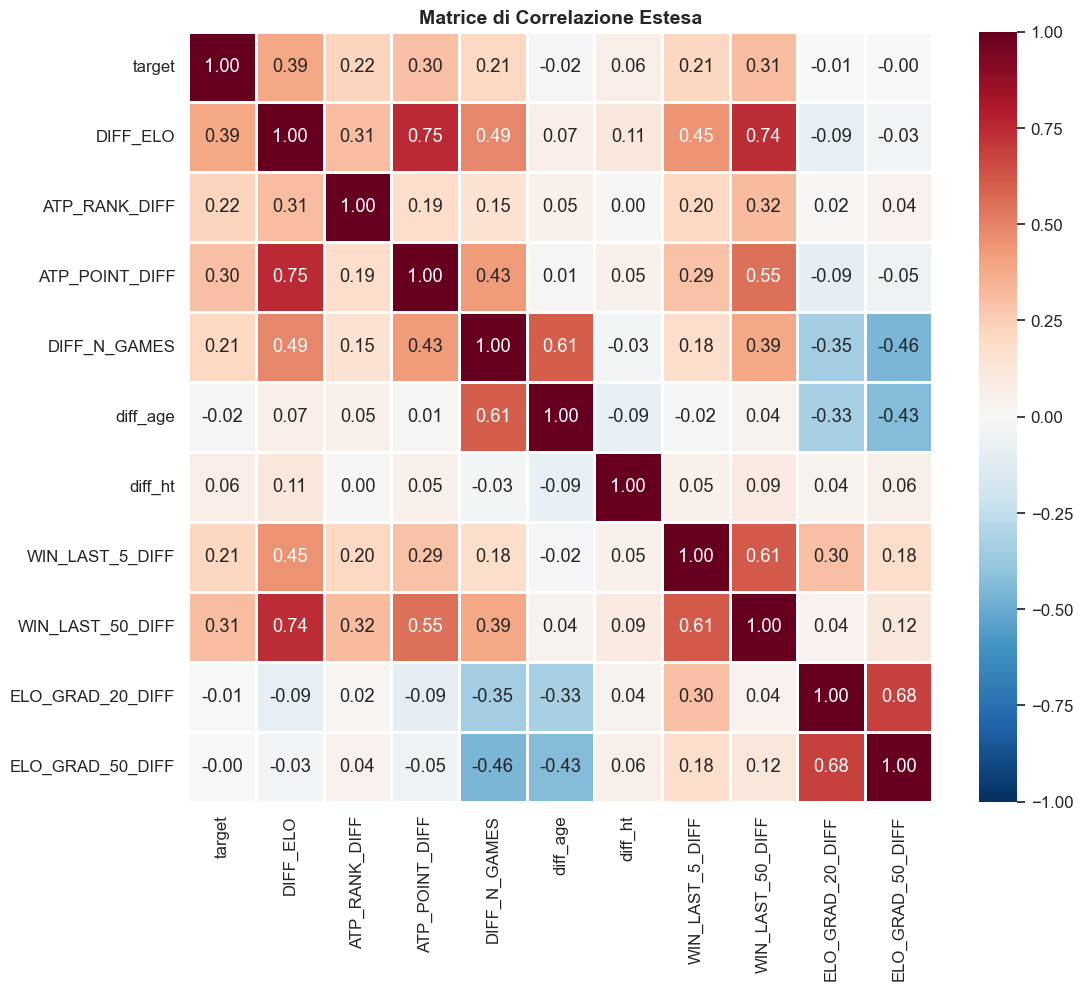


5.1: MATRICE DI CORRELAZIONE ESTESA
OBIETTIVO: Identificare quali feature hanno il maggior potere discriminante rispetto al target.
- La feature 'DIFF_ELO' (corr: 0.39) si conferma il miglior predittore.
- Interessante notare che 'ATP_POINT_DIFF' (0.30) correla meglio 
  del semplice 'ATP_RANK_DIFF' (0.22).
- Si osserva un'alta multicollinearità tra ELO e Punti ATP (0.75), suggerendo che misurano 
  aspetti simili della forza del giocatore.

Giocatore: Jannik Sinner - Match trovati: 353
Giocatore: Carlos Alcaraz - Match trovati: 265
Giocatore: Novak Djokovic - Match trovati: 1363


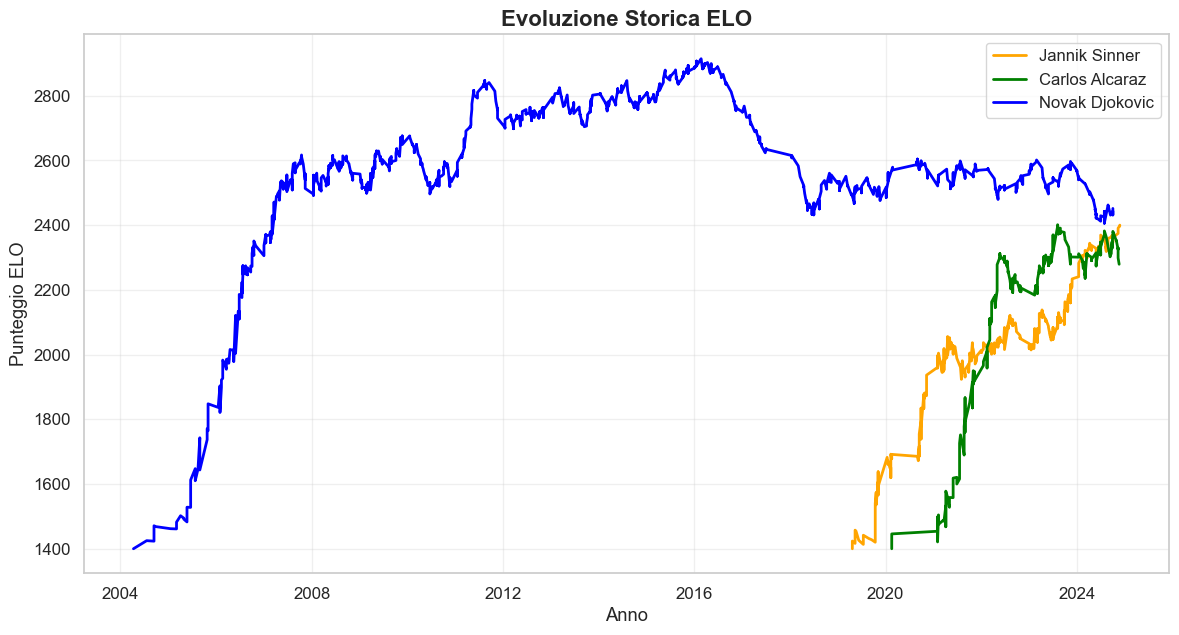


5.2: EVOLUZIONE STORICA ELO
OBIETTIVO: Validare la dinamicità del sistema ELO su carriere reali.
- Djokovic: Rappresenta la 'stabilità del dominio' con un ELO altissimo mantenuto per oltre un decennio.
- Alcaraz & Sinner: Mostrano una crescita verticale (gradienti elevati) dal 2020 ad oggi.
- Il sistema cattura bene i passaggi di consegne generazionali e i picchi di forma relativi.



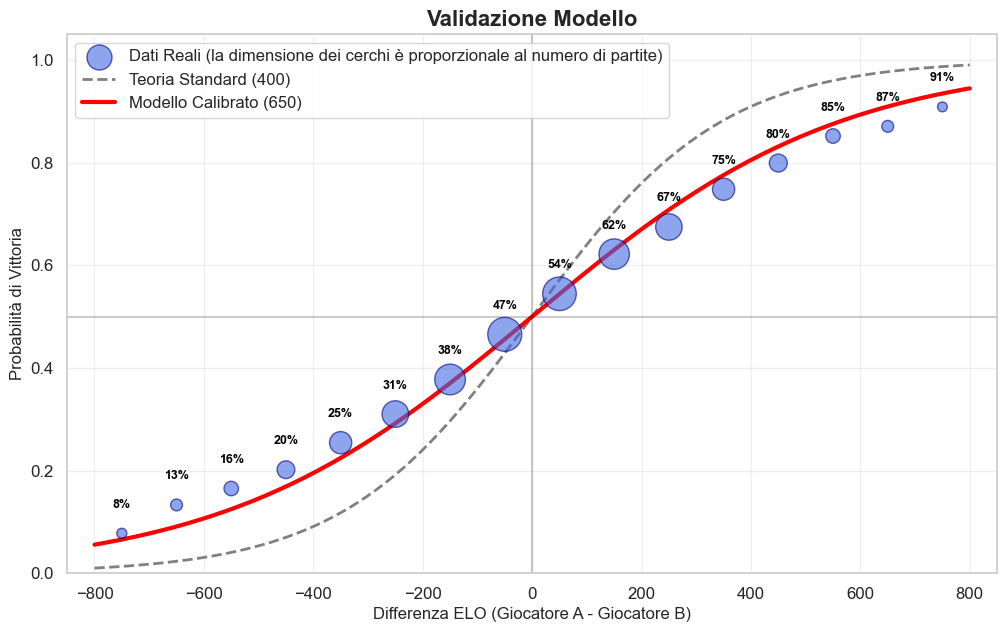


5.3: VALIDAZIONE E CALIBRAZIONE DELLA PROBABILITÀ
OBIETTIVO: Confrontare la teoria matematica ELO con i risultati reali del dataset.
- La Teoria Standard (K=400, linea tratteggiata) tende a sovrastimare la certezza dei risultati.
- Il Modello Calibrato (K=650, linea rossa) fitta meglio i dati reali (pallini blu).
- Conclusione: Il tennis ha una componente di incertezza (upset) maggiore rispetto agli scacchi.
  Una differenza di 400 punti ELO nel tennis non garantisce il 91%, ma circa l'80% di vittoria.



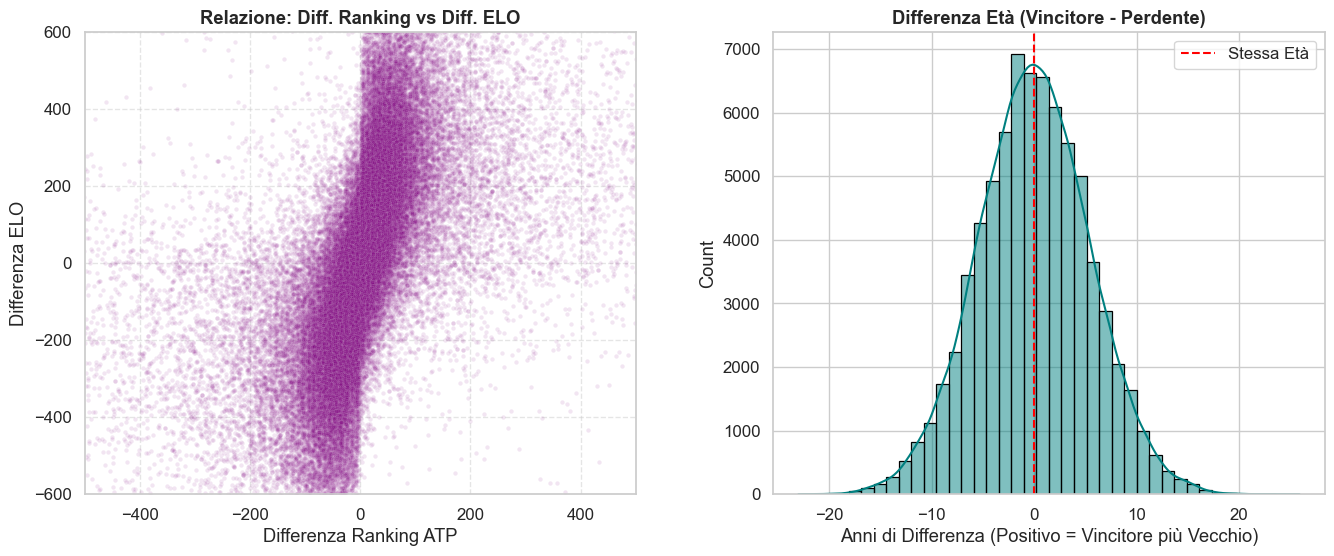


5.4: DISTRIBUZIONI E RELAZIONI TRA FEATURE
GRAFICO A (ELO vs Ranking):
- Esiste una relazione logaritmica/non lineare. Ai vertici della classifica, 
  piccole variazioni di ranking corrispondono a enormi divari di punteggio ELO.

GRAFICO B (Differenza Età):
- La distribuzione è centrata sullo zero. Vincere o perdere non dipende strettamente dall'età,
  confermando che l'esperienza (anzianità) e l'atletismo (gioventù) spesso si compensano.



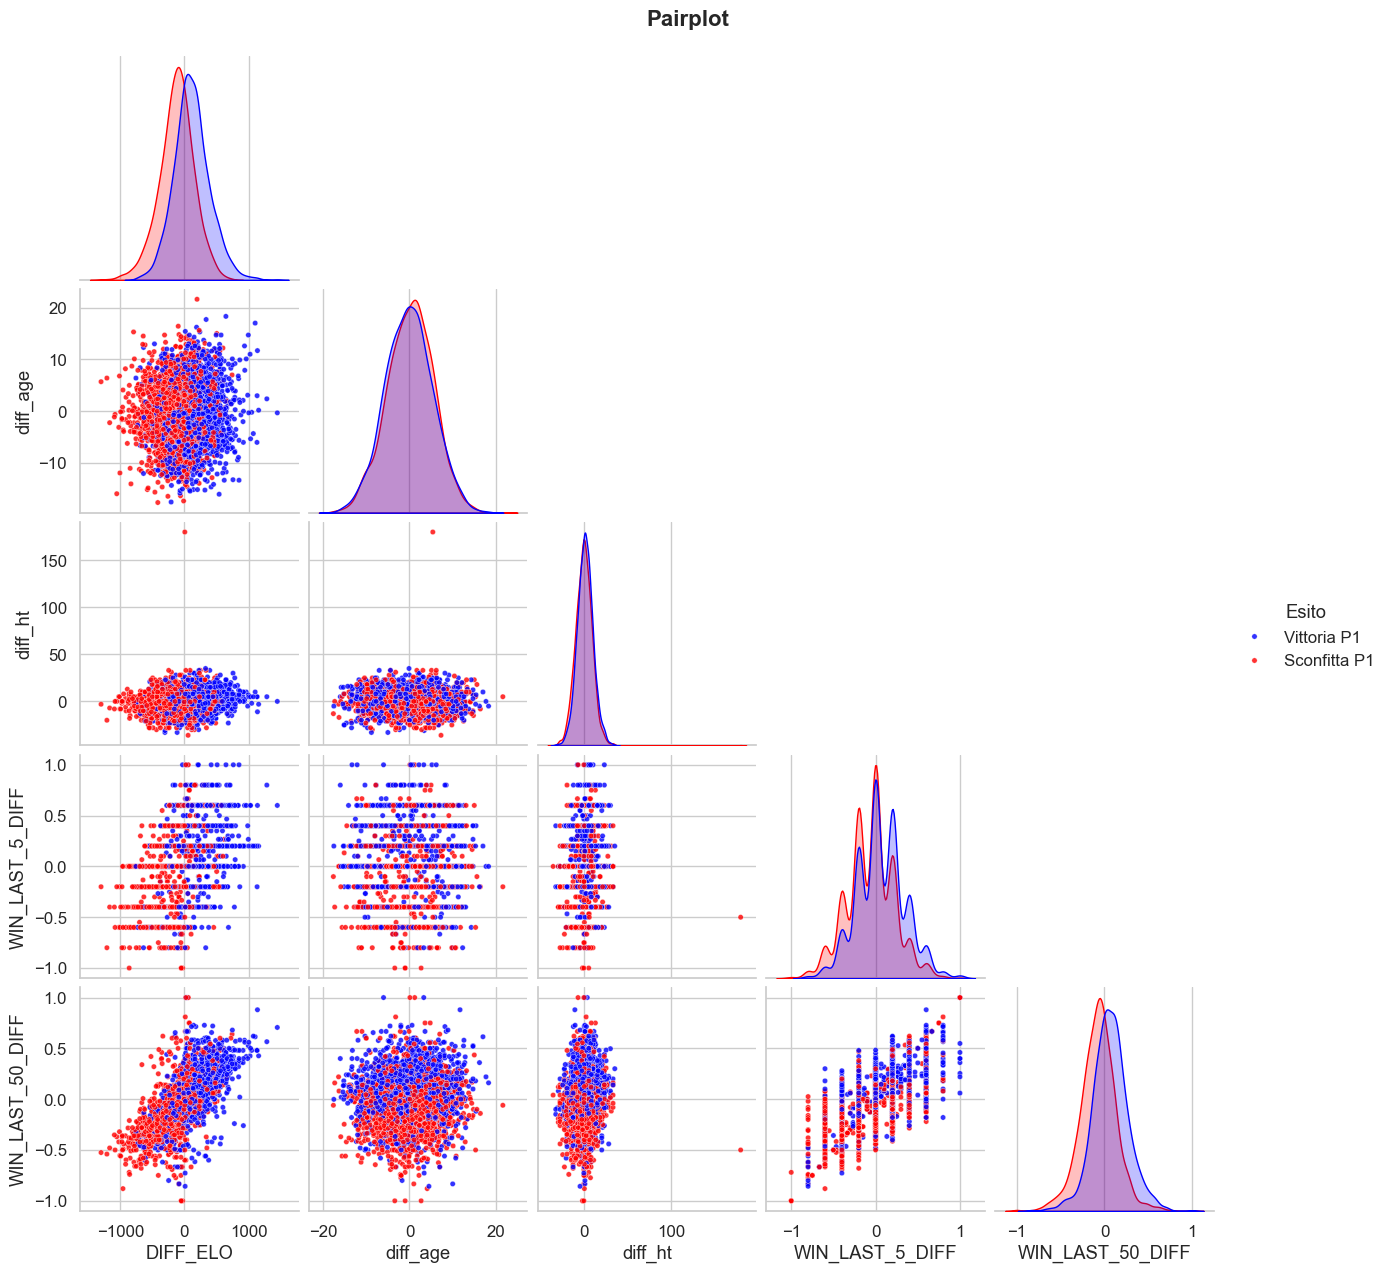


5.5: PAIRPLOT - RELAZIONI MULTIDIMENSIONALI
OBIETTIVO: Visualizzare la separazione delle classi (Vittoria/Sconfitta) nello spazio delle feature.
- Si nota una chiara diagonale di separazione nei plot che coinvolgono DIFF_ELO e WIN_LAST_50_DIFF.
- Le zone blu (Vittoria P1) e rosse (Sconfitta P1) sono ben distinte agli estremi dei grafici,
  mentre si sovrappongono nell'origine (match equilibrati).
- Questo conferma che il modello ha segnali forti su cui lavorare per l'addestramento.



In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np  

# Configurazioni grafiche
sns.set_context("notebook", font_scale=1.1)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Caricamento Dataset 
try:
    df_human = pd.read_csv("datasets_produced\\dataset_enriched.csv")
    df_ml = pd.read_csv("datasets_produced\\dataset_ml_ready.csv")
except FileNotFoundError:
    print("ERRORE: File csv non trovati. Esegui prima le celle precedenti!")

# ==========================================
# 1. MATRICE DI CORRELAZIONE ESTESA
# ==========================================

extended_feats = [
    'target', 
    'DIFF_ELO',          # La regina
    'ATP_RANK_DIFF',     # Classifica ufficiale
    'ATP_POINT_DIFF',    # Punti ATP (più preciso del rank)
    'DIFF_N_GAMES',      # Esperienza (Veterano vs Novellino)
    'diff_age',          # Gioventù vs Esperienza
    'diff_ht',           # Altezza 
    'WIN_LAST_5_DIFF',   # Forma Breve
    'WIN_LAST_50_DIFF',  # Forma Lunga
    'ELO_GRAD_20_DIFF',  # Trend Breve
    'ELO_GRAD_50_DIFF'   # Trend Lungo
]


corr_matrix = df_ml[extended_feats].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1, linewidths=1)
plt.title("Matrice di Correlazione Estesa", fontsize=14, fontweight='bold')
plt.show()

print("\n" + "="*80)
print("5.1: MATRICE DI CORRELAZIONE ESTESA")
print("="*80)
print("OBIETTIVO: Identificare quali feature hanno il maggior potere discriminante rispetto al target.")
print(f"- La feature 'DIFF_ELO' (corr: {corr_matrix['target']['DIFF_ELO']:.2f}) si conferma il miglior predittore.")
print(f"- Interessante notare che 'ATP_POINT_DIFF' ({corr_matrix['target']['ATP_POINT_DIFF']:.2f}) correla meglio ")
print(f"  del semplice 'ATP_RANK_DIFF' ({corr_matrix['target']['ATP_RANK_DIFF']:.2f}).")
print("- Si osserva un'alta multicollinearità tra ELO e Punti ATP (0.75), suggerendo che misurano ")
print("  aspetti simili della forza del giocatore.")
print("="*80 + "\n")

# ==========================================
# 2. ELO EVOLUTION: SINNER vs ALCARAZ vs DJOKOVIC
# ==========================================

target_players = ["Jannik Sinner", "Carlos Alcaraz", "Novak Djokovic"]
colors = {"Jannik Sinner": "orange", "Carlos Alcaraz": "green", "Novak Djokovic": "blue"}

plt.figure(figsize=(14, 7))

found_data = False 

for player in target_players:
    # Cerchiamo il giocatore sia come vincitore che come perdente
    w_mask = df_human['winner_name'].str.contains(player, case=False, na=False)
    l_mask = df_human['loser_name'].str.contains(player, case=False, na=False)
    
    # Estraiamo Data e ELO
    w_data = df_human.loc[w_mask, ['tourney_date', 'w_elo']].rename(columns={'w_elo': 'elo'})
    l_data = df_human.loc[l_mask, ['tourney_date', 'l_elo']].rename(columns={'l_elo': 'elo'})
    
    # Uniamo tutto
    player_history = pd.concat([w_data, l_data])
    
    player_history['date'] = pd.to_datetime(player_history['tourney_date'], errors='coerce')
    
    # Ordiniamo cronologicamente
    player_history = player_history.sort_values('date').dropna()
    
    print(f"Giocatore: {player} - Match trovati: {len(player_history)}")
    
    if not player_history.empty:
        found_data = True
        plt.plot(player_history['date'], player_history['elo'], 
                 label=player, color=colors.get(player, 'gray'), linewidth=2)

if found_data:
    plt.title("Evoluzione Storica ELO", fontsize=16, fontweight='bold')
    plt.ylabel("Punteggio ELO")
    plt.xlabel("Anno")
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("ATTENZIONE: Nessun dato trovato per i giocatori selezionati. Controlla i nomi nel CSV.")


print("\n" + "="*80)
print("5.2: EVOLUZIONE STORICA ELO")
print("="*80)
print("OBIETTIVO: Validare la dinamicità del sistema ELO su carriere reali.")
print("- Djokovic: Rappresenta la 'stabilità del dominio' con un ELO altissimo mantenuto per oltre un decennio.")
print("- Alcaraz & Sinner: Mostrano una crescita verticale (gradienti elevati) dal 2020 ad oggi.")
print("- Il sistema cattura bene i passaggi di consegne generazionali e i picchi di forma relativi.")
print("="*80 + "\n")

# ==========================================
# 3. VALIDAZIONE DEL MODELLO
# ==========================================

# Creiamo intervalli di ELO
bins = list(range(-800, 801, 100)) 
df_ml['elo_bin'] = pd.cut(df_ml['DIFF_ELO'], bins=bins)

# Calcoliamo Statistiche
calibration = df_ml.groupby('elo_bin', observed=False)['target'].agg(['mean', 'count']).reset_index()
calibration.rename(columns={'mean': 'target'}, inplace=True) 
calibration['mid_point'] = calibration['elo_bin'].apply(lambda x: x.mid).astype(float)

# Calcoliamo Curve Teoriche
x_theoretical = np.linspace(-800, 800, 200)
y_std = 1 / (1 + 10 ** (-x_theoretical / 400))
best_scale = 650
y_calibrated = 1 / (1 + 10 ** (-x_theoretical / best_scale))

# --- PLOT ---
plt.figure(figsize=(12, 7))

# DISEGNIAMO I DATI REALI 
# Calcolo dimensioni proporzionali (min 50, max 600)
# Normalizziamo i conteggi tra 0 e 1 per scalare i pallini
counts = calibration['count']
min_s, max_s = 50, 600
if counts.max() > counts.min():
    sizes = (counts - counts.min()) / (counts.max() - counts.min()) * (max_s - min_s) + min_s
else:
    sizes = 300 # Dimensione fissa se tutti i bin sono uguali

plt.scatter(
    calibration['mid_point'], calibration['target'], 
    s=sizes, 
    color='royalblue', alpha=0.6, 
    label='Dati Reali (la dimensione dei cerchi è proporzionale al numero di partite)', 
    zorder=5,
    edgecolor='navy' 
)

#DISEGNIAMO LE CURVE
plt.plot(x_theoretical, y_std, color='gray', linestyle='--', linewidth=2, label='Teoria Standard (400)')
plt.plot(x_theoretical, y_calibrated, color='red', linewidth=3, label=f'Modello Calibrato ({best_scale})')

# Decorazioni
plt.title(f"Validazione Modello", fontsize=16, fontweight='bold')
plt.xlabel("Differenza ELO (Giocatore A - Giocatore B)", fontsize=12)
plt.ylabel("Probabilità di Vittoria", fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.ylim(0, 1.05)
plt.xlim(-850, 850)
plt.grid(True, alpha=0.3)
plt.axhline(0.5, linestyle='-', color='black', alpha=0.2)
plt.axvline(0, linestyle='-', color='black', alpha=0.2)

# Etichette percentuali
for line in range(0, calibration.shape[0]):
    mid = calibration.mid_point[line]
    val = calibration.target[line]
    count = calibration['count'][line]
    if count > 50 and not np.isnan(val): 
        plt.text(mid, val + 0.05, f"{val*100:.0f}%", horizontalalignment='center', color='black', fontsize=9, fontweight='bold')

plt.show()
print("\n" + "="*80)
print("5.3: VALIDAZIONE E CALIBRAZIONE DELLA PROBABILITÀ")
print("="*80)
print("OBIETTIVO: Confrontare la teoria matematica ELO con i risultati reali del dataset.")
print("- La Teoria Standard (K=400, linea tratteggiata) tende a sovrastimare la certezza dei risultati.")
print("- Il Modello Calibrato (K=650, linea rossa) fitta meglio i dati reali (pallini blu).")
print("- Conclusione: Il tennis ha una componente di incertezza (upset) maggiore rispetto agli scacchi.")
print(f"  Una differenza di 400 punti ELO nel tennis non garantisce il 91%, ma circa l'80% di vittoria.")
print("="*80 + "\n")
# ==========================================
# 4. MULTI-PLOT ESPLORATIVO 
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 
plt.subplots_adjust(wspace=0.25) # Spazio orizzontale

# --- GRAFICO A: ELO vs RANKING ---
sns.scatterplot(x='ATP_RANK_DIFF', y='DIFF_ELO', data=df_ml, 
                alpha=0.1, ax=axes[0], color='purple', s=10)
axes[0].set_title("Relazione: Diff. Ranking vs Diff. ELO", fontweight='bold')
axes[0].set_xlabel("Differenza Ranking ATP")
axes[0].set_ylabel("Differenza ELO")
axes[0].set_xlim(-500, 500)
axes[0].set_ylim(-600, 600)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- GRAFICO B: DISTRIBUZIONE ETÀ ---
sns.histplot(df_ml['diff_age'], bins=40, kde=True, ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title("Differenza Età (Vincitore - Perdente)", fontweight='bold')
axes[1].set_xlabel("Anni di Differenza (Positivo = Vincitore più Vecchio)")
axes[1].axvline(0, color='red', linestyle='--', label='Stessa Età')
axes[1].legend()

plt.show()

print("\n" + "="*80)
print("5.4: DISTRIBUZIONI E RELAZIONI TRA FEATURE")
print("="*80)
print("GRAFICO A (ELO vs Ranking):")
print("- Esiste una relazione logaritmica/non lineare. Ai vertici della classifica, ")
print("  piccole variazioni di ranking corrispondono a enormi divari di punteggio ELO.")
print("\nGRAFICO B (Differenza Età):")
print("- La distribuzione è centrata sullo zero. Vincere o perdere non dipende strettamente dall'età,")
print("  confermando che l'esperienza (anzianità) e l'atletismo (gioventù) spesso si compensano.")
print("="*80 + "\n")
# ======================
# 5. PAIRPLOT 
# ======================

important_feats = [
    'target',            
    'DIFF_ELO',          
    'diff_age',          
    'diff_ht',           
    'WIN_LAST_5_DIFF',   
    'WIN_LAST_50_DIFF'   
]

# CAMPIONAMENTO 
# Usiamo un campione di 5000 match casuali.
df_sample = df_ml[important_feats].sample(n=5000, random_state=42).copy()

df_sample['Esito'] = df_sample['target'].map({1: 'Vittoria P1', 0: 'Sconfitta P1'})

# 4. Generazione Pairplot
sns.pairplot(
    df_sample.drop(columns=['target']), # Usiamo la colonna 'Esito' per il colore
    hue='Esito', 
    palette={'Vittoria P1': 'blue', 'Sconfitta P1': 'red'},
    corner=True, 
    plot_kws={'alpha': 0.8, 's': 15}, 
    height=2.5
)

plt.suptitle("Pairplot", y=1.02, fontsize=16, fontweight='bold')
plt.show()

print("\n" + "="*80)
print("5.5: PAIRPLOT - RELAZIONI MULTIDIMENSIONALI")
print("="*80)
print("OBIETTIVO: Visualizzare la separazione delle classi (Vittoria/Sconfitta) nello spazio delle feature.")
print("- Si nota una chiara diagonale di separazione nei plot che coinvolgono DIFF_ELO e WIN_LAST_50_DIFF.")
print("- Le zone blu (Vittoria P1) e rosse (Sconfitta P1) sono ben distinte agli estremi dei grafici,")
print("  mentre si sovrappongono nell'origine (match equilibrati).")
print("- Questo conferma che il modello ha segnali forti su cui lavorare per l'addestramento.")
print("="*80 + "\n")

---
---

## 6. Analisi delle Componenti Principali (PCA)

--- ESECUZIONE PCA  ---
Dataset caricato con successo.
Feature totali selezionate: 57
Righe Train (2000-2022): 68844
Righe Test (2023-2024): 6009

PCA STEP 1: NORMALIZZAZIONE
- Fondamentale per la PCA: porta tutte le feature (Elo, Anni, Altezza) sulla stessa scala.
- Evitiamo che variabili con range grandi (es. Rank Points) dominino su variabili piccole (es. Age).

PCA STEP 2: CALCOLO DELLE COMPONENTI PRINCIPALI


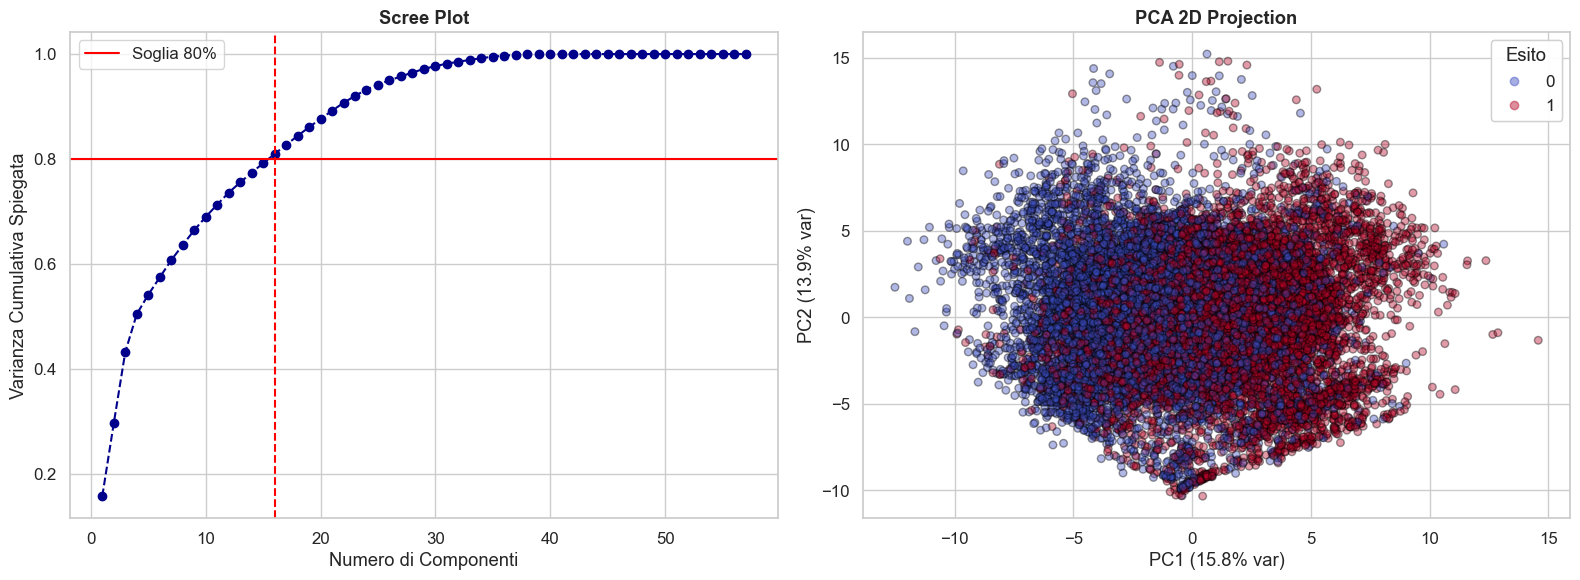


CONCLUSIONE ANALISI PCA
1. COMPRESSIONE: Abbiamo ridotto 57 variabili a 16 componenti mantenendo l'80% della varianza.
   Questo suggerisce che il dataset è solido ma presenta una forte correlazione interna.

2. SIGNIFICATO PC1 (Strength Axis):
WIN_LAST_100_DIFF    0.294044
WIN_LAST_50_DIFF     0.286713
DIFF_ELO             0.278604
WIN_LAST_25_DIFF     0.268723
DIFF_N_GAMES         0.238219
ATP_POINT_DIFF       0.233925
DIFF_SURF_ELO        0.217708
p1_win_last_100      0.191405
WIN_LAST_5_DIFF      0.187375
p1_win_last_50       0.186073
Name: PC1, dtype: float64

- NOTA: PC1 è dominata dai DIFFERENZIALI (Elo, Win%, Games).
- Interpretazione: PC1 misura quanto il P1 sia 'più forte' del P2.

Interpretazione PC2 (Verifica Contesto):
p2_win_last_25     0.279169
p2_win_last_50     0.275223
p2_win_last_100    0.267458
p2_elo             0.267307
p2_win_last_5      0.247938
p1_elo             0.235607
p1_win_last_100    0.223173
p1_win_last_50     0.220065
p1_win_last_25     0.213726
p2_ra

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_context("notebook", font_scale=1.1)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("--- ESECUZIONE PCA  ---")

# 1. CARICAMENTO DATI
try:
    df_pca = pd.read_csv("datasets_produced\\dataset_ml_ready.csv")
    print("Dataset caricato con successo.")
except FileNotFoundError:
    print("Errore: dataset_ml_ready.csv non trovato.")

if 'tourney_date' in df_pca.columns:
    df_pca['tourney_date'] = pd.to_datetime(df_pca['tourney_date'])

# 2. SELEZIONE DELLE FEATURE
# Escludiamo: ID, Nomi, Date e Statistiche POST-match (Ace, DF, Break Points) perchè sono inutili o costituiscono leakage
cols_to_use = [
    # Contesto Match
    'best_of', 'round_num',
    'surface_Hard', 'surface_Clay', 'surface_Grass', 'surface_Carpet', # Le tue colonne surface
    
    # Player 1 - Fisico e Ranking
    'p1_rank', 'p1_rank_points', 'p1_age', 'p1_ht', 'p1_is_left', 
    'p1_matches_played',
    
    # Player 1 - ELO e Trend
    'p1_elo', 'p1_surface_elo', 'p1_prob_elo', 'p1_h2h',
    'p1_win_last_5', 'p1_win_last_25', 'p1_win_last_50', 'p1_win_last_100',
    'p1_elo_grad_20', 'p1_elo_grad_35', 'p1_elo_grad_50', 'p1_elo_grad_100',

    # Player 2 - Fisico e Ranking
    'p2_rank', 'p2_rank_points', 'p2_age', 'p2_ht', 'p2_is_left', 
    'p2_matches_played',

    # Player 2 - ELO e Trend
    'p2_elo', 'p2_surface_elo', 'p2_h2h',
    'p2_win_last_5', 'p2_win_last_25', 'p2_win_last_50', 'p2_win_last_100',
    'p2_elo_grad_20', 'p2_elo_grad_35', 'p2_elo_grad_50', 'p2_elo_grad_100',

    # Differenziali
    'ATP_RANK_DIFF', 'ATP_POINT_DIFF', 'DIFF_ELO', 'DIFF_N_GAMES',
    'diff_age', 'diff_ht', 'DIFF_SURF_ELO', 'DIFF_H2H',
    'WIN_LAST_5_DIFF', 'WIN_LAST_25_DIFF', 'WIN_LAST_50_DIFF', 'WIN_LAST_100_DIFF',
    'ELO_GRAD_20_DIFF', 'ELO_GRAD_35_DIFF', 'ELO_GRAD_50_DIFF', 'ELO_GRAD_100_DIFF'
]

valid_features = [c for c in cols_to_use if c in df_pca.columns]
print(f"Feature totali selezionate: {len(valid_features)}")

# 3. SPLIT CRONOLOGICO (Train < 2023, Test >= 2023)
train_mask = df_pca['tourney_date'] < '2023-01-01'
test_mask = df_pca['tourney_date'] >= '2023-01-01'

X_train = df_pca.loc[train_mask, valid_features]
y_train = df_pca.loc[train_mask, 'target']

X_test = df_pca.loc[test_mask, valid_features]

print(f"Righe Train (2000-2022): {X_train.shape[0]}")
print(f"Righe Test (2023-2024): {X_test.shape[0]}")

# 4. NORMALIZZAZIONE
print("\n" + "="*80)
print("PCA STEP 1: NORMALIZZAZIONE")
print("="*80)
print("- Fondamentale per la PCA: porta tutte le feature (Elo, Anni, Altezza) sulla stessa scala.")
print("- Evitiamo che variabili con range grandi (es. Rank Points) dominino su variabili piccole (es. Age).")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 5. APPLICAZIONE PCA
print("\n" + "="*80)
print("PCA STEP 2: CALCOLO DELLE COMPONENTI PRINCIPALI")
print("="*80)
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

loadings = pd.DataFrame(
    pca.components_.T,  # Trasponiamo per avere Feature sulle righe e PC sulle colonne
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=valid_features
)

# ==========================================
# VISUALIZZAZIONE RISULTATI
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRAFICO A: Scree Plot 
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_80 = np.argmax(cum_var >= 0.80) + 1 

axes[0].plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='--', color='darkblue')
axes[0].axhline(y=0.80, color='red', linestyle='-', label='Soglia 80%')
axes[0].axvline(x=n_80, color='red', linestyle='--')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xlabel('Numero di Componenti')
axes[0].set_ylabel('Varianza Cumulativa Spiegata')
axes[0].legend()
axes[0].grid(True)

# GRAFICO B: PC1 vs PC2 Scatterplot
# Campioniamo 5000 punti casuali per non rendere il grafico illeggibile
if X_train_pca.shape[0] > 35000:
    idx = np.random.choice(X_train_pca.shape[0], 35000, replace=False)
else:
    idx = np.arange(X_train_pca.shape[0])

scatter = axes[1].scatter(
    X_train_pca[idx, 0], 
    X_train_pca[idx, 1], 
    c=y_train.iloc[idx], 
    cmap='coolwarm', alpha=0.4, edgecolor='k', s=30
)
axes[1].set_title('PCA 2D Projection', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
legend1 = axes[1].legend(*scatter.legend_elements(), title="Esito")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

# ANALISI TESTUALE FINALE
print("\n" + "="*80)
print("CONCLUSIONE ANALISI PCA")
print("="*80)
print(f"1. COMPRESSIONE: Abbiamo ridotto 57 variabili a {n_80} componenti mantenendo l'80% della varianza.")
print("   Questo suggerisce che il dataset è solido ma presenta una forte correlazione interna.")

print("\n2. SIGNIFICATO PC1 (Strength Axis):")
top_10 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
print(top_10)
print("\n- NOTA: PC1 è dominata dai DIFFERENZIALI (Elo, Win%, Games).")
print("- Interpretazione: PC1 misura quanto il P1 sia 'più forte' del P2.")

print("\nInterpretazione PC2 (Verifica Contesto):")
print(loadings['PC2'].abs().sort_values(ascending=False).head(10))

print("\n3. ANALISI CLUSTERING:")
print("- Nel grafico 2D, la separazione cromatica tra Rosso e Blu lungo PC1 conferma ")
print("  che la differenza di forza storica è il miglior predittore dell'esito finale.")
print("="*80)

---
---

## 7. Modellazione: Decision Tree (CART)
Il primo approccio alla classificazione è stato effettuato tramite un Albero di Decisione (CART). Questo modello è stato scelto per la sua capacità di catturare relazioni non lineari e per l'elevata interpretabilità dei risultati.

--- ADDESTRAMENTO DECISION TREE (CART) ---
Training su 68844 partite (2000-2022)
Testing su 6009 partite (2023-2024)

ACCURACY: 64.45%
PRECISION: 64.00%
RECALL: 64.95%


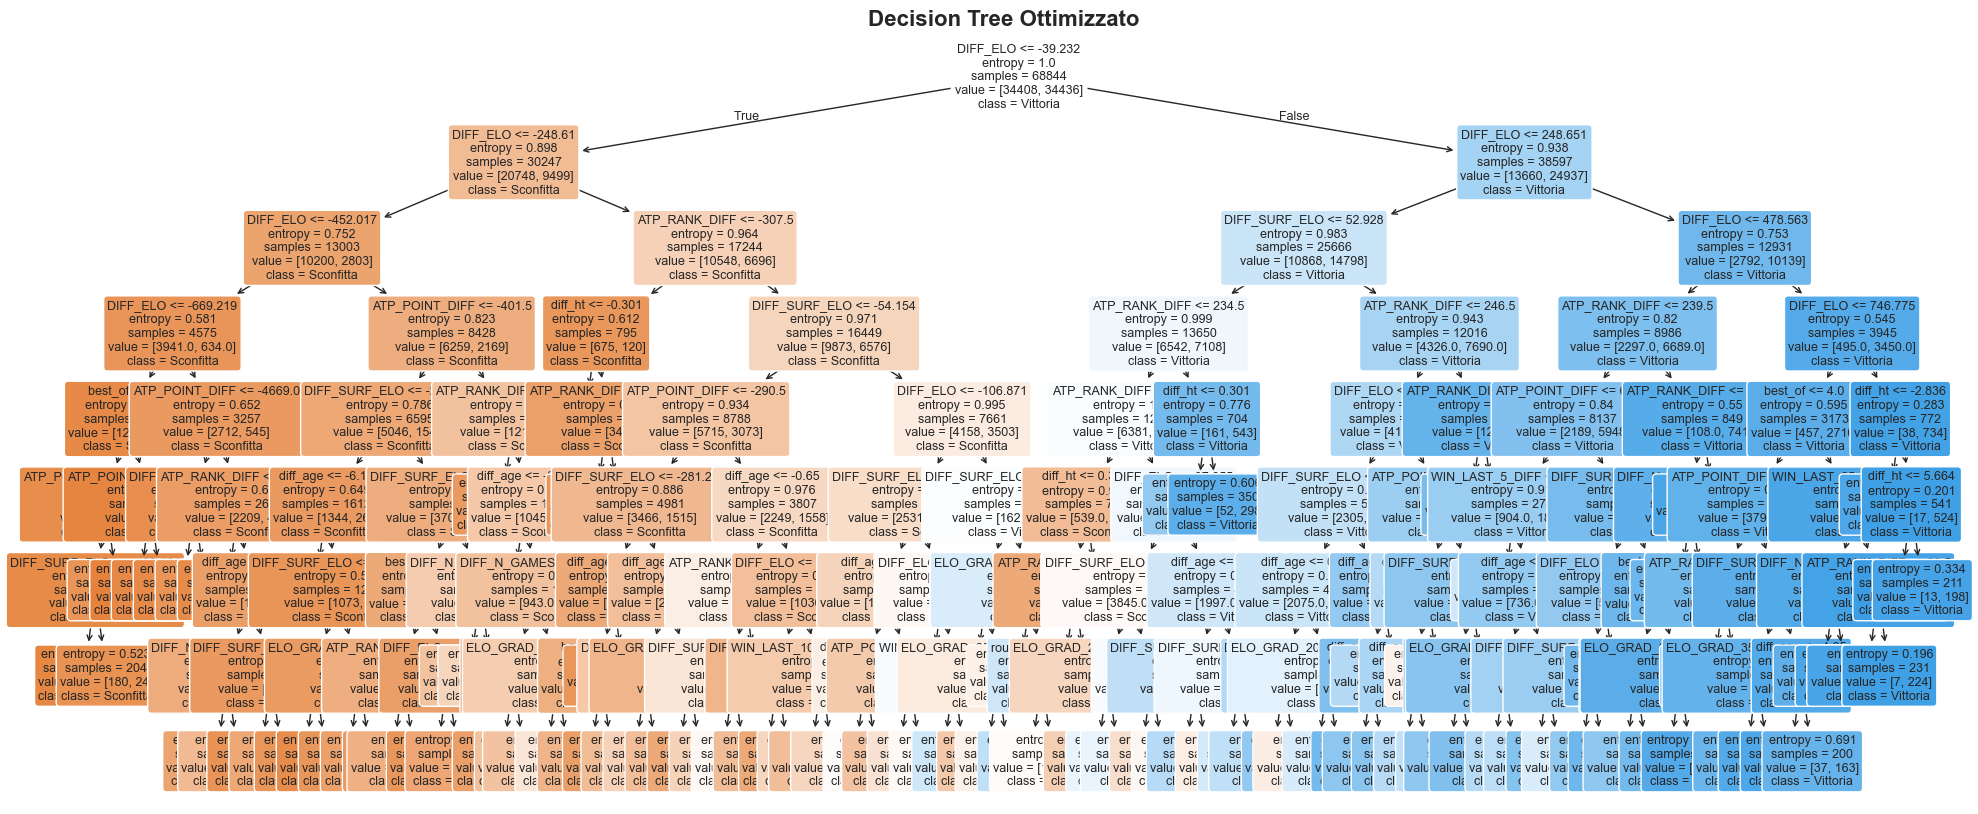


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.65      0.64      0.64      3025
           1       0.64      0.65      0.64      2984

    accuracy                           0.64      6009
   macro avg       0.64      0.64      0.64      6009
weighted avg       0.64      0.64      0.64      6009



In [14]:
# ==========================================
# 9. MODELLO 1: DECISION TREE (CART) 
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

# Configurazioni
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("--- ADDESTRAMENTO DECISION TREE (CART) ---")

# 1. CARICAMENTO E PREPARAZIONE
try:
    df_ml = pd.read_csv("datasets_produced\\dataset_ml_ready.csv")
    df_ml['tourney_date'] = pd.to_datetime(df_ml['tourney_date'])
except:
    print("Errore: Carica prima il file dataset_ml_ready.csv")

# Feature Selection
features = [
    # --- CONTESTO DEL MATCH ---
    'best_of',             
    'round_num',           
    'surface_Hard', 'surface_Clay', 'surface_Grass', 'surface_Carpet', 
    
    # --- CARATTERISTICHE FISICHE ---
    'diff_age',            
    'diff_ht',             
    'p1_is_left',         
    'p2_is_left',         
    
    # --- RANKING E ELO  ---
    'DIFF_ELO',            
    'DIFF_SURF_ELO',       
    'ATP_RANK_DIFF',       
    'ATP_POINT_DIFF',      
    'DIFF_H2H',            
    
    # --- ESPERIENZA ---
    'DIFF_N_GAMES',        
    
    # --- FORMA RECENTE ---
    'WIN_LAST_5_DIFF',     # Forma brevissimo termine
    'WIN_LAST_25_DIFF',    # Forma breve termine
    'WIN_LAST_50_DIFF',    # Forma medio termine
    'WIN_LAST_100_DIFF',   # Forma lungo termine
    
    # --- TREND DI MIGLIORAMENTO ---
    'ELO_GRAD_20_DIFF',    
    'ELO_GRAD_35_DIFF',    
    'ELO_GRAD_50_DIFF',    
    'ELO_GRAD_100_DIFF'    
]

# 2. SPLIT CRONOLOGICO
# Train: 2000-2022 | Test: 2023-2024
train_mask = df_ml['tourney_date'] < '2023-01-01'
test_mask = df_ml['tourney_date'] >= '2023-01-01'

X_train = df_ml.loc[train_mask, features]
y_train = df_ml.loc[train_mask, 'target']
X_test = df_ml.loc[test_mask, features]
y_test = df_ml.loc[test_mask, 'target']

print(f"Training su {len(X_train)} partite (2000-2022)")
print(f"Testing su {len(X_test)} partite (2023-2024)")

# 3. ADDESTRAMENTO MODELLO
clf_tree = DecisionTreeClassifier(
    criterion='entropy',      
    max_depth=8,              
    min_samples_leaf=200,     
    random_state=42
)

clf_tree.fit(X_train, y_train)

# 4. VALUTAZIONE
y_pred = clf_tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
print(f"\nACCURACY: {acc:.2%}")
print(f"PRECISION: {prec:.2%}")
print(f"RECALL: {rec:.2%}")

# 5. VISUALIZZAZIONE ALBERO 
plt.figure(figsize=(24, 10))
plot_tree(
    clf_tree, 
    feature_names=features, 
    class_names=['Sconfitta', 'Vittoria'], 
    filled=True, 
    rounded=True, 
    fontsize=9,
    max_depth=8 
)
plt.title(f"Decision Tree Ottimizzato", fontsize=16, fontweight='bold')
plt.show()


# Stampa report testuale
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))


Calcolo in corso............ Fatto!


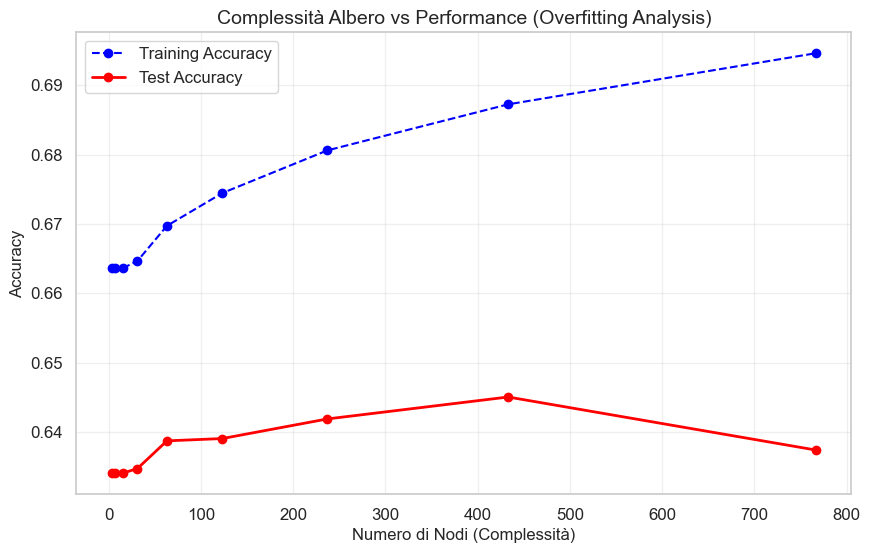

--- RISULTATO ---
Miglior Accuracy Test: 0.6450
Ottenuta con 433 nodi (Max Depth: 8)

FEATURE IMPORTANCE ANALYSIS


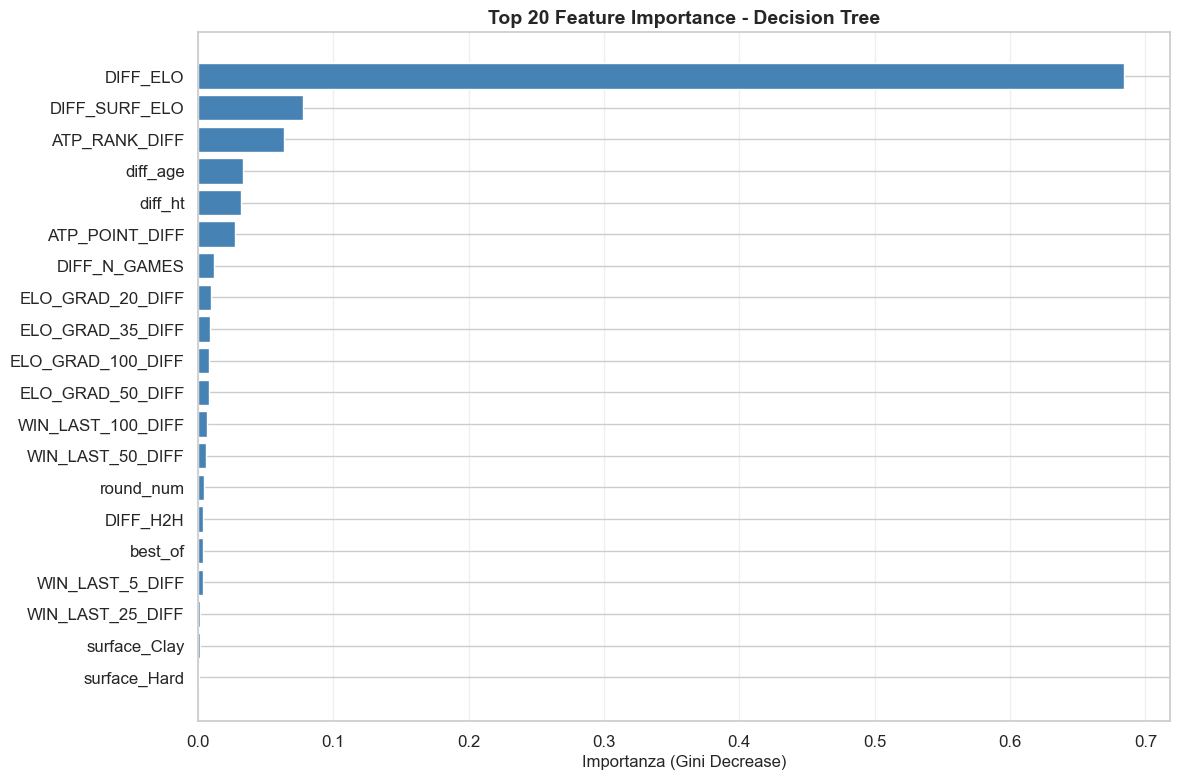


Top 10 Features:
DIFF_ELO                       0.6842
DIFF_SURF_ELO                  0.0776
ATP_RANK_DIFF                  0.0639
diff_age                       0.0336
diff_ht                        0.0317
ATP_POINT_DIFF                 0.0276
DIFF_N_GAMES                   0.0121
ELO_GRAD_20_DIFF               0.0096
ELO_GRAD_35_DIFF               0.0091
ELO_GRAD_100_DIFF              0.0084


In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd

# ===========================
# PREPARAZIONE DATI 
# ===========================
try:
    X_train.shape
except NameError:
    print("Ricarico i dati...")
    df_ml = pd.read_csv("datasets_produced\\dataset_ml_ready.csv")
    df_ml['tourney_date'] = pd.to_datetime(df_ml['tourney_date'])
    
    features = [
        'best_of', 'round_num', 'surface_Hard', 'surface_Clay', 'surface_Grass', 'surface_Carpet',
        'diff_age', 'diff_ht', 'p1_is_left', 'p2_is_left',
        'DIFF_ELO', 'DIFF_SURF_ELO', 'ATP_RANK_DIFF', 'ATP_POINT_DIFF', 'DIFF_H2H',
        'DIFF_N_GAMES', 'WIN_LAST_5_DIFF', 'WIN_LAST_25_DIFF', 'WIN_LAST_50_DIFF', 'WIN_LAST_100_DIFF',
        'ELO_GRAD_20_DIFF', 'ELO_GRAD_35_DIFF', 'ELO_GRAD_50_DIFF', 'ELO_GRAD_100_DIFF'
    ]
    
    train_mask = df_ml['tourney_date'] < '2023-01-01'
    test_mask = df_ml['tourney_date'] >= '2023-01-01'
    
    X_train = df_ml.loc[train_mask, features]
    y_train = df_ml.loc[train_mask, 'target']
    X_test = df_ml.loc[test_mask, features]
    y_test = df_ml.loc[test_mask, 'target']
    
    print(f"Dati caricati: Training {len(X_train)} partite, Testing {len(X_test)} partite")

# ==========================================
# OVERFITTING ANALYSIS
# ==========================================

# 1. Definiamo un range di profondità da testare
depths = range(1, 10)

train_scores = []
test_scores = []
node_counts = []

print("\nCalcolo in corso...", end="")

for d in depths:
    # Creiamo e addestriamo l'albero con la profondità corrente
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    
    # Salviamo il numero di nodi reali dell'albero
    node_counts.append(clf.tree_.node_count)
    
    # Salviamo le accuracy
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))
    print(".", end="")

print(" Fatto!")

# 2. Generiamo il Grafico
plt.figure(figsize=(10, 6))

# Linea Training (Solitamente sale sempre)
plt.plot(node_counts, train_scores, marker='o', label='Training Accuracy', color='blue', linestyle='--')

# Linea Test (Sale e poi scende/stabilizza)
plt.plot(node_counts, test_scores, marker='o', label='Test Accuracy', color='red', linewidth=2)

# Abbellimenti
plt.title('Complessità Albero vs Performance (Overfitting Analysis)', fontsize=14)
plt.xlabel('Numero di Nodi (Complessità)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Mostriamo il grafico
plt.show()

# 3. Troviamo il punto ottimale
best_idx = np.argmax(test_scores)
print(f"--- RISULTATO ---")
print(f"Miglior Accuracy Test: {test_scores[best_idx]:.4f}")
print(f"Ottenuta con {node_counts[best_idx]} nodi (Max Depth: {depths[best_idx]})")

# 4. FEATURE IMPORTANCE del modello ottimale
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Estraiamo le feature importance dal modello clf (l'ultimo creato nel loop)
feature_importance = clf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot Top 20 Features
plt.figure(figsize=(12, 8))
top_20 = importance_df.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='steelblue')
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importanza (Gini Decrease)', fontsize=12)
plt.title('Top 20 Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
for idx, row in importance_df.head(10).iterrows():
    print(f"{row['Feature']:<30} {row['Importance']:.4f}")
print("="*80)

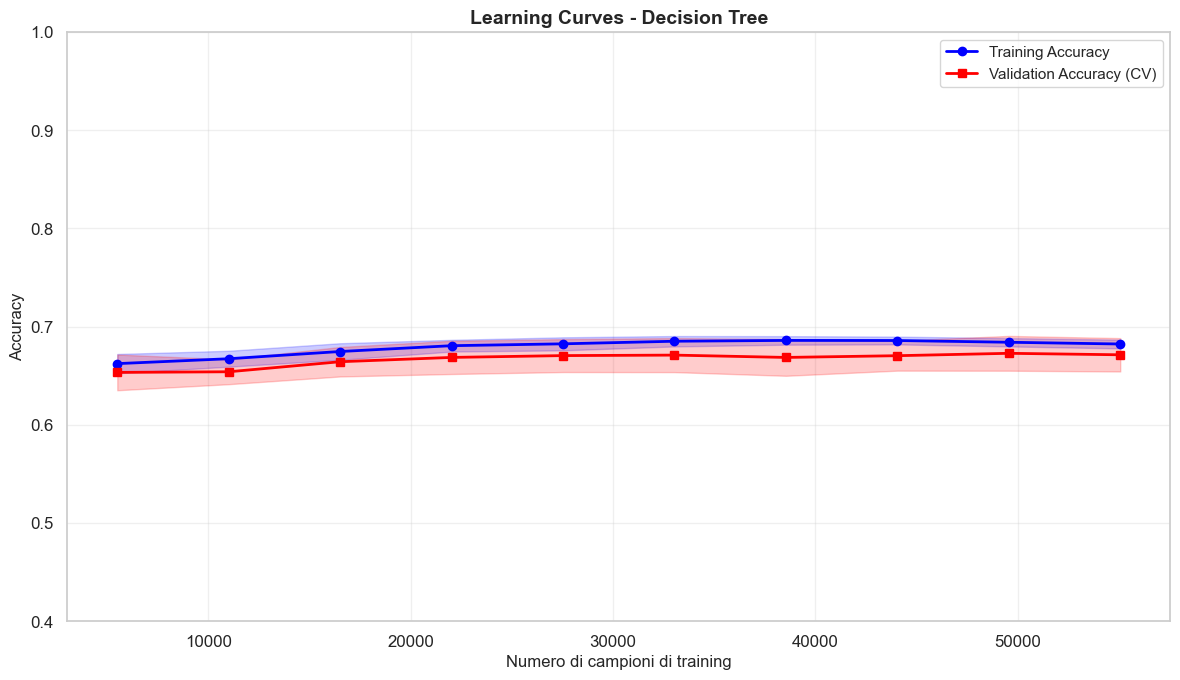


LEARNING CURVES ANALYSIS
Training Accuracy finale:   0.6822 ± 0.0045
Validation Accuracy finale: 0.6712 ± 0.0170
Gap (Train - Val):         0.0110

BUON FIT: Training e validation sono vicini


In [16]:

# ==========================================
# LEARNING CURVES - Decision Tree
# ==========================================
# Analizza come cambia accuracy al variare della quantità di dati di training

from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Creiamo il modello Decision Tree ottimizzato
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_leaf=200,
    random_state=42
)

# Calcola le learning curves
train_sizes, train_scores, val_scores = learning_curve(
    dt_model,
    X_train, y_train,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),  
    n_jobs=-1  
)

# Calcola media e deviazione standard
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot Learning Curves
plt.figure(figsize=(12, 7))

# Linea Training
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy', color='blue', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')

# Linea Validation
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy (CV)', color='red', linewidth=2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='red')

# Abbellimenti
plt.title('Learning Curves - Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Numero di campioni di training', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0.4, 1.0])

# Mostra il grafico
plt.tight_layout()
plt.show()

# Analisi e interpretazione
print("\n" + "="*80)
print("LEARNING CURVES ANALYSIS")
print("="*80)
print(f"Training Accuracy finale:   {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"Validation Accuracy finale: {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
print(f"Gap (Train - Val):         {(train_mean[-1] - val_mean[-1]):.4f}")

gap = train_mean[-1] - val_mean[-1]
if gap > 0.10:
    print("\nOVERFITTING DETECTION: Gap significativo tra training e validation")
    print("    Suggerimento: aumentare la regolarizzazione (max_depth, min_samples_leaf)")
elif gap < 0.02:
    print("\nBUON FIT: Training e validation sono vicini")
else:
    print("\nLEGGERO OVERFITTING: Gap moderato tra training e validation")

print("="*80)

---
---
## 8. Modellazione: Rete Neurale

--- ADDESTRAMENTO RETE NEURALE (MLP) CON OTTIMIZZAZIONE ---
Dati normalizzati. Avvio Grid Search...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

MIGLIORI PARAMETRI: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (128, 128, 64, 32), 'learning_rate_init': 0.001}
Miglior Accuracy (durante il training): 68.07%
------------------------------
ACCURACY FINALE SUL TEST SET: 65.60%
------------------------------


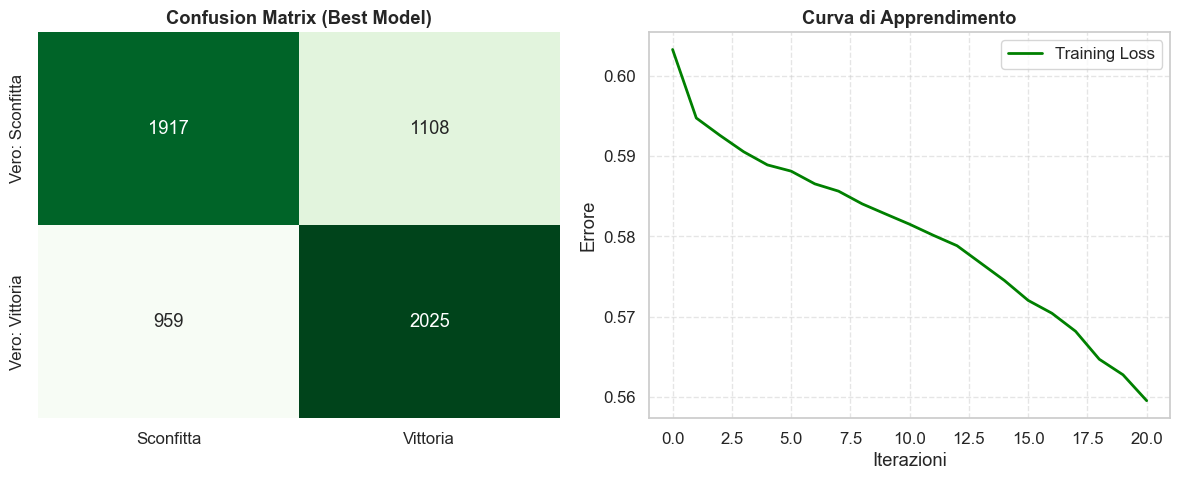

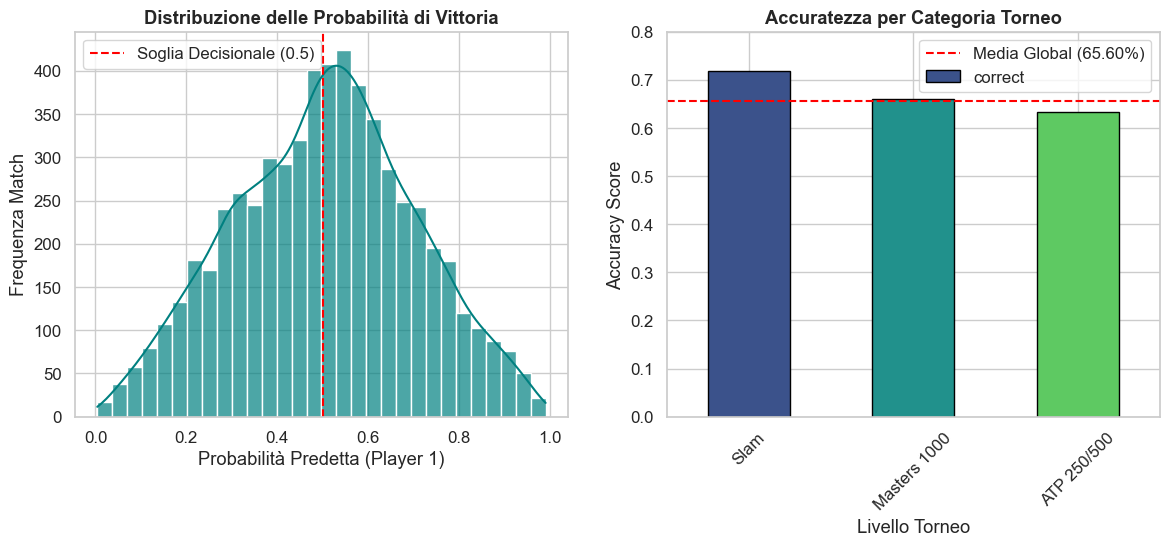

In [17]:
# ==========================================
# 10. MODELLO 2: RETE NEURALE 
# ==========================================
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("--- ADDESTRAMENTO RETE NEURALE (MLP) CON OTTIMIZZAZIONE ---")

# 1. PREPARAZIONE FEATURES

# Filtri temporali
train_mask = df_ml['tourney_date'] < '2023-01-01'
test_mask = df_ml['tourney_date'] >= '2023-01-01'

# Creazione matrici X e y
X_train_opt = df_ml.loc[train_mask, features].fillna(0)
y_train_opt = df_ml.loc[train_mask, 'target']
X_test_opt = df_ml.loc[test_mask, features].fillna(0)
y_test_opt = df_ml.loc[test_mask, 'target']

# 2. SCALING 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_opt)
X_test_scaled = scaler.transform(X_test_opt)

print("Dati normalizzati. Avvio Grid Search...")

# 3. CONFIGURAZIONE GRID SEARCH
param_grid = {
    'hidden_layer_sizes': [
        (128, 128, 64, 32),     
        (128, 128, 128, 64),     
        (256, 128, 64, 32),      
        (256, 256, 128, 64)      
    ],
    
    'alpha': [0.005, 0.01, 0.02], 
    
    'activation': ['relu', 'tanh'],  
    
    'learning_rate_init': [0.001]
}

# Modello base
mlp_base = MLPClassifier(
    max_iter=150, 
    early_stopping=True, 
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42
)

# Il "Torneo"
grid_search_mlp = GridSearchCV(
    mlp_base,
    param_grid,
    cv=3,              # 3 round di validazione per ogni modello
    scoring='accuracy',
    n_jobs=-1,         
    verbose=1
)

grid_search_mlp.fit(X_train_scaled, y_train_opt)

# 4. RISULTATI
best_mlp = grid_search_mlp.best_estimator_

print(f"\nMIGLIORI PARAMETRI: {grid_search_mlp.best_params_}")
print(f"Miglior Accuracy (durante il training): {grid_search_mlp.best_score_:.2%}")

# 5. VALUTAZIONE FINALE (TEST 2023-2024)
y_pred_final = best_mlp.predict(X_test_scaled)
acc_final = accuracy_score(y_test_opt, y_pred_final)

print("-" * 30)
print(f"ACCURACY FINALE SUL TEST SET: {acc_final:.2%}")
print("-" * 30)

# 6. GRAFICI
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_opt, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Sconfitta', 'Vittoria'],
            yticklabels=['Vero: Sconfitta', 'Vero: Vittoria'])
plt.title(f"Confusion Matrix (Best Model)", fontweight='bold')

# Curva di Loss
plt.subplot(1, 2, 2)
plt.plot(best_mlp.loss_curve_, label='Training Loss', color='green', linewidth=2)
plt.title("Curva di Apprendimento", fontweight='bold')
plt.xlabel("Iterazioni")
plt.ylabel("Errore")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# --- 7. DISTRIBUZIONE DELLE PROBABILITÀ ---
y_probs = best_mlp.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(y_probs, bins=30, kde=True, color='teal', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='Soglia Decisionale (0.5)')
plt.title("Distribuzione delle Probabilità di Vittoria", fontweight='bold')
plt.xlabel("Probabilità Predetta (Player 1)")
plt.ylabel("Frequenza Match")
plt.legend()

# --- 8. ACCURACY PER CATEGORIA TORNEO ---

# Verifichiamo se la colonna esiste, altrimenti proviamo a recuperarla 
# Se hai usato tourney_level per creare altre feature, assicurati che non sia stata droppata
if 'tourney_level' in df_ml.columns:
    test_data_with_labels = df_ml.loc[test_mask].copy()
    test_data_with_labels['pred'] = y_pred_final
    test_data_with_labels['correct'] = (test_data_with_labels['pred'] == test_data_with_labels['target'])

    # Mappa i codici (G, M, A) in nomi più leggibili se vuoi
    mapping = {'G': 'Slam', 'M': 'Masters 1000', 'A': 'ATP 250/500', 'C': 'Challenger'}
    test_data_with_labels['tourney_level'] = test_data_with_labels['tourney_level'].map(mapping)

    acc_per_level = test_data_with_labels.groupby('tourney_level')['correct'].mean().sort_values(ascending=False)

    plt.subplot(1, 2, 2)
    colors = sns.color_palette("viridis", len(acc_per_level))
    acc_per_level.plot(kind='bar', color=colors, edgecolor='black')
    plt.title("Accuratezza per Categoria Torneo", fontweight='bold')
    plt.ylabel("Accuracy Score")
    plt.xlabel("Livello Torneo")
    plt.ylim(0, 0.8) 
    plt.axhline(acc_final, color='red', linestyle='--', label=f'Media Global ({acc_final:.2%})')
    plt.xticks(rotation=45)
    plt.legend()
else:
    print("ERRORE: La colonna 'tourney_level' non è presente nel dataset. ")

---
---
## 9. Validazione e Risultati

--- REPORT DI VALUTAZIONE FINALE ---

VALUTAZIONE: DECISION TREE
              precision    recall  f1-score   support

   Sconfitta       0.65      0.64      0.64      3025
    Vittoria       0.64      0.65      0.64      2984

    accuracy                           0.64      6009
   macro avg       0.64      0.64      0.64      6009
weighted avg       0.64      0.64      0.64      6009

ROC AUC Score: 0.7070
Accuracy con Intervallo di Confidenza (95%): 64.45% ± 1.21%
   (Range reale stimato: da 63.24% a 65.66%)

VALUTAZIONE: NEURAL NETWORK
              precision    recall  f1-score   support

   Sconfitta       0.67      0.63      0.65      3025
    Vittoria       0.65      0.68      0.66      2984

    accuracy                           0.66      6009
   macro avg       0.66      0.66      0.66      6009
weighted avg       0.66      0.66      0.66      6009

ROC AUC Score: 0.7204
Accuracy con Intervallo di Confidenza (95%): 65.60% ± 1.20%
   (Range reale stimato: da 64.40% a 66.80%

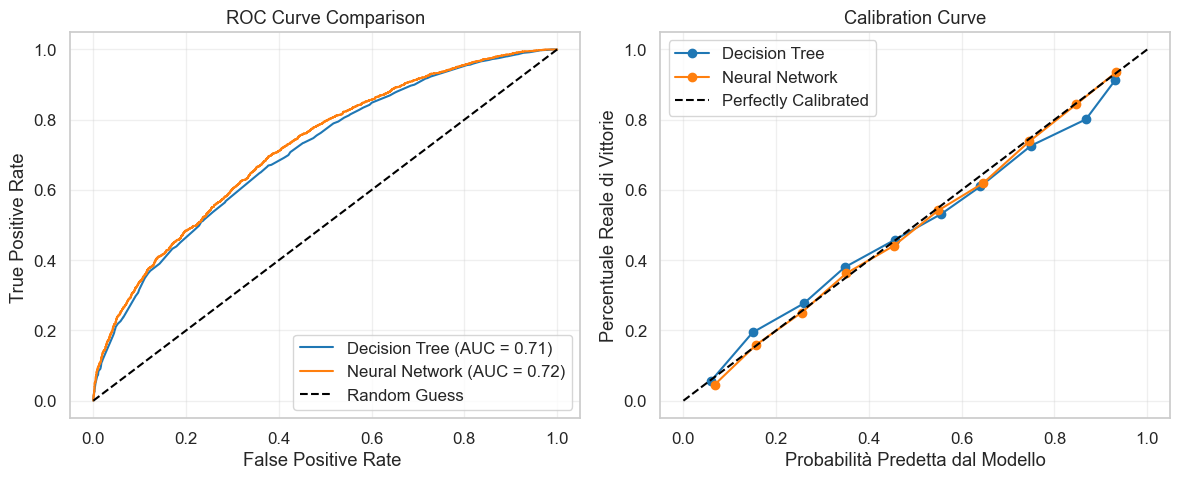

In [18]:
# ==========================================
# EVALUATION & CREDIBILITY
# ==========================================
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

print("--- REPORT DI VALUTAZIONE FINALE ---")

# Definiamo una funzione per calcolare l'Intervallo di Confidenza (95%)
def get_confidence_interval(accuracy, n_samples):
    margin = 1.96 * np.sqrt((accuracy * (1 - accuracy)) / n_samples)
    return margin

models_to_eval = [
    ('Decision Tree', clf_tree, X_test_opt),    
    ('Neural Network', best_mlp, X_test_scaled), 

]

plt.figure(figsize=(12, 5))

# Ciclo su ogni modello
for name, model, X_val in models_to_eval:
    print(f"\nVALUTAZIONE: {name.upper()}")
    
    # 1. Predizioni
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1] # Probabilità di vittoria 
    
    # 2. Metriche Base 
    print(classification_report(y_test_opt, y_pred, target_names=['Sconfitta', 'Vittoria']))
    
    # 3. ROC AUC
    auc = roc_auc_score(y_test_opt, y_prob)
    print(f"ROC AUC Score: {auc:.4f}")
    
    # 4. Confidence Interval
    acc = accuracy_score(y_test_opt, y_pred)
    margin = get_confidence_interval(acc, len(y_test_opt))
    print(f"Accuracy con Intervallo di Confidenza (95%): {acc:.2%} ± {margin:.2%}")
    print(f"   (Range reale stimato: da {acc-margin:.2%} a {acc+margin:.2%})")

    # 5. Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test_opt, y_prob)
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

    # 6. Plot Calibration Curve 
    prob_true, prob_pred = calibration_curve(y_test_opt, y_prob, n_bins=10)
    plt.subplot(1, 2, 2)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

# --- FINITURA GRAFICI ---

# Grafico ROC
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate ')
plt.ylabel('True Positive Rate ')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Grafico Calibrazione
plt.subplot(1, 2, 2)
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Probabilità Predetta dal Modello')
plt.ylabel('Percentuale Reale di Vittorie')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
---
## 10. Australian Open 2025

#### 10.1. Verifica Risultati Torneo

In [19]:
from collections import defaultdict

# 1. Carichiamo il database giocatori
df_players = pd.read_csv("datasets_produced\\players_2025_ready.csv").set_index('player_name')

# 2. Definiamo i profili di due giocatori mancanti (Stime basate su dati reali fine 2024)
missing_profiles = {
    'Tristan Boyer': {
        'elo': 1450, 'hard_elo': 1460, 'clay_elo': 1440, 'grass_elo': 1400,
        'rank': 134, 'rank_points': 450, 'age': 23.7, 'ht': 188, 'is_left': 0,
        'matches_played': 5, 'win_last_5': 0.4, 'win_last_25': 0.4, 'win_last_50': 0.4, 'win_last_100': 0.4,
        'elo_grad_20': 10, 'elo_grad_35': 10, 'elo_grad_50': 10, 'elo_grad_100': 10
    },
    'Gauthier Onclin': {
        'elo': 1410, 'hard_elo': 1410, 'clay_elo': 1420, 'grass_elo': 1380,
        'rank': 218, 'rank_points': 280, 'age': 23.9, 'ht': 180, 'is_left': 0,
        'matches_played': 2, 'win_last_5': 0.3, 'win_last_25': 0.3, 'win_last_50': 0.3, 'win_last_100': 0.3,
        'elo_grad_20': 5, 'elo_grad_35': 5, 'elo_grad_50': 5, 'elo_grad_100': 5
    }
}

# 3. Aggiungiamoli al dataframe se non ci sono già
count_added = 0
for name, stats in missing_profiles.items():
    if name not in df_players.index:
        df_players.loc[name] = pd.Series(stats)
        count_added += 1

print(f"Aggiunti {count_added} giocatori mancanti al database (Boyer/Onclin).")

# ==============================================================================
# FASE 1: PREPARAZIONE DATI
# ==============================================================================

df_historical = pd.read_csv("datasets_produced\\dataset_ml_ready.csv") 
df_tournament = pd.read_csv("datasets_produced\\AO 2025.csv", sep=';')

df_tournament.dropna(subset=['p1_name', 'p2_name'], inplace=True)
df_tournament.columns = df_tournament.columns.str.strip()
df_tournament['p1_name'] = df_tournament['p1_name'].str.strip()
df_tournament['p2_name'] = df_tournament['p2_name'].str.strip()

print(f"Match validi nel tabellone: {len(df_tournament)}")

# Calcolo H2H tra i giocatori del torneo
tournament_players = set(df_tournament['p1_name']).union(set(df_tournament['p2_name']))
relevant_history = df_historical[
    df_historical['p1_name'].isin(tournament_players) & 
    df_historical['p2_name'].isin(tournament_players)
]

print("Calcolo H2H...")
h2h_stats = defaultdict(lambda: defaultdict(int))
for idx, row in relevant_history.iterrows():
    w = row['p1_name'] if row['target'] == 1 else row['p2_name']
    l = row['p2_name'] if row['target'] == 1 else row['p1_name']
    h2h_stats[w][l] += 1

# ==============================================================================
# FASE 2: COSTRUZIONE DATASET INFERENZA
# ==============================================================================
features_list = [
    'best_of', 'round_num',
    'surface_Hard', 'surface_Clay', 'surface_Grass', 'surface_Carpet', 
    'diff_age', 'diff_ht', 'p1_is_left', 'p2_is_left', 
    'DIFF_ELO', 'DIFF_SURF_ELO', 'ATP_RANK_DIFF', 'ATP_POINT_DIFF', 
    'DIFF_H2H', 'DIFF_N_GAMES', 
    'WIN_LAST_5_DIFF', 'WIN_LAST_25_DIFF', 'WIN_LAST_50_DIFF', 'WIN_LAST_100_DIFF', 
    'ELO_GRAD_20_DIFF', 'ELO_GRAD_35_DIFF', 'ELO_GRAD_50_DIFF', 'ELO_GRAD_100_DIFF'
]

match_data = []
skipped = 0

for index, row in df_tournament.iterrows():
    p1 = row['p1_name']
    p2 = row['p2_name']
    
    # Ora Boyer e Onclin sono in df_players, quindi non dovrebbero esserci errori
    if p1 not in df_players.index or p2 not in df_players.index:
        skipped += 1
        continue
        
    stats_p1 = df_players.loc[p1]
    stats_p2 = df_players.loc[p2]
    
    wins_p1 = h2h_stats.get(p1, {}).get(p2, 0)
    wins_p2 = h2h_stats.get(p2, {}).get(p1, 0)
    
    match_row = {
        'best_of': 5, 
        'round_num': row['round_num'],
        'surface_Hard': 1, 'surface_Clay': 0, 'surface_Grass': 0, 'surface_Carpet': 0,
        'diff_age': stats_p1['age'] - stats_p2['age'],
        'diff_ht': stats_p1['ht'] - stats_p2['ht'],
        'p1_is_left': stats_p1['is_left'],
        'p2_is_left': stats_p2['is_left'],
        'DIFF_ELO': stats_p1['elo'] - stats_p2['elo'],
        'DIFF_SURF_ELO': stats_p1['hard_elo'] - stats_p2['hard_elo'],
        'ATP_RANK_DIFF': stats_p1['rank'] - stats_p2['rank'],
        'ATP_POINT_DIFF': stats_p1['rank_points'] - stats_p2['rank_points'],
        'DIFF_H2H': wins_p1 - wins_p2, 
        'DIFF_N_GAMES': stats_p1['matches_played'] - stats_p2['matches_played'],
        'WIN_LAST_5_DIFF': stats_p1['win_last_5'] - stats_p2['win_last_5'],
        'WIN_LAST_25_DIFF': stats_p1['win_last_25'] - stats_p2['win_last_25'],
        'WIN_LAST_50_DIFF': stats_p1['win_last_50'] - stats_p2['win_last_50'],
        'WIN_LAST_100_DIFF': stats_p1['win_last_100'] - stats_p2['win_last_100'],
        'ELO_GRAD_20_DIFF': stats_p1['elo_grad_20'] - stats_p2['elo_grad_20'],
        'ELO_GRAD_35_DIFF': stats_p1['elo_grad_35'] - stats_p2['elo_grad_35'],
        'ELO_GRAD_50_DIFF': stats_p1['elo_grad_50'] - stats_p2['elo_grad_50'],
        'ELO_GRAD_100_DIFF': stats_p1['elo_grad_100'] - stats_p2['elo_grad_100']
    }
    match_data.append(match_row)

print(f"Generati dati per {len(match_data)} match (Saltati: {skipped})")

X_ao_2025 = pd.DataFrame(match_data)[features_list].fillna(0)

y_full = df_historical['target']
X_full = df_historical[features_list]

scaler_final = StandardScaler()
X_full_scaled = scaler_final.fit_transform(X_full)

# utilizziamo gli stessi iperparaemetri ottimizzati in precedenza    
final_model = MLPClassifier(
    hidden_layer_sizes=(128, 128, 64, 32),
    activation='relu', 
    alpha=0.01, 
    max_iter=150, 
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42
)
final_model.fit(X_full_scaled, y_full)

# Predizione
X_ao_scaled = scaler_final.transform(X_ao_2025)
probs = final_model.predict_proba(X_ao_scaled)[:, 1]

# Salvataggio
df_result = df_tournament.iloc[:len(X_ao_2025)].copy()
df_result['Model_Prob_P1'] = probs
df_result['Model_Prediction'] = (probs > 0.5).astype(int)
df_result['Correct'] = (df_result['Model_Prediction'] == df_result['target']).astype(int)

print(f"\nAccuratezza Finale su {len(df_result)} match: {df_result['Correct'].mean():.2%}")
df_result.to_csv("datasets_produced\\AO_2025_FULL_RESULTS.csv", index=False)

Aggiunti 2 giocatori mancanti al database (Boyer/Onclin).
Match validi nel tabellone: 127
Calcolo H2H...
Generati dati per 127 match (Saltati: 0)

Accuratezza Finale su 127 match: 71.65%


#### 10.2. Simulazione Australian Open

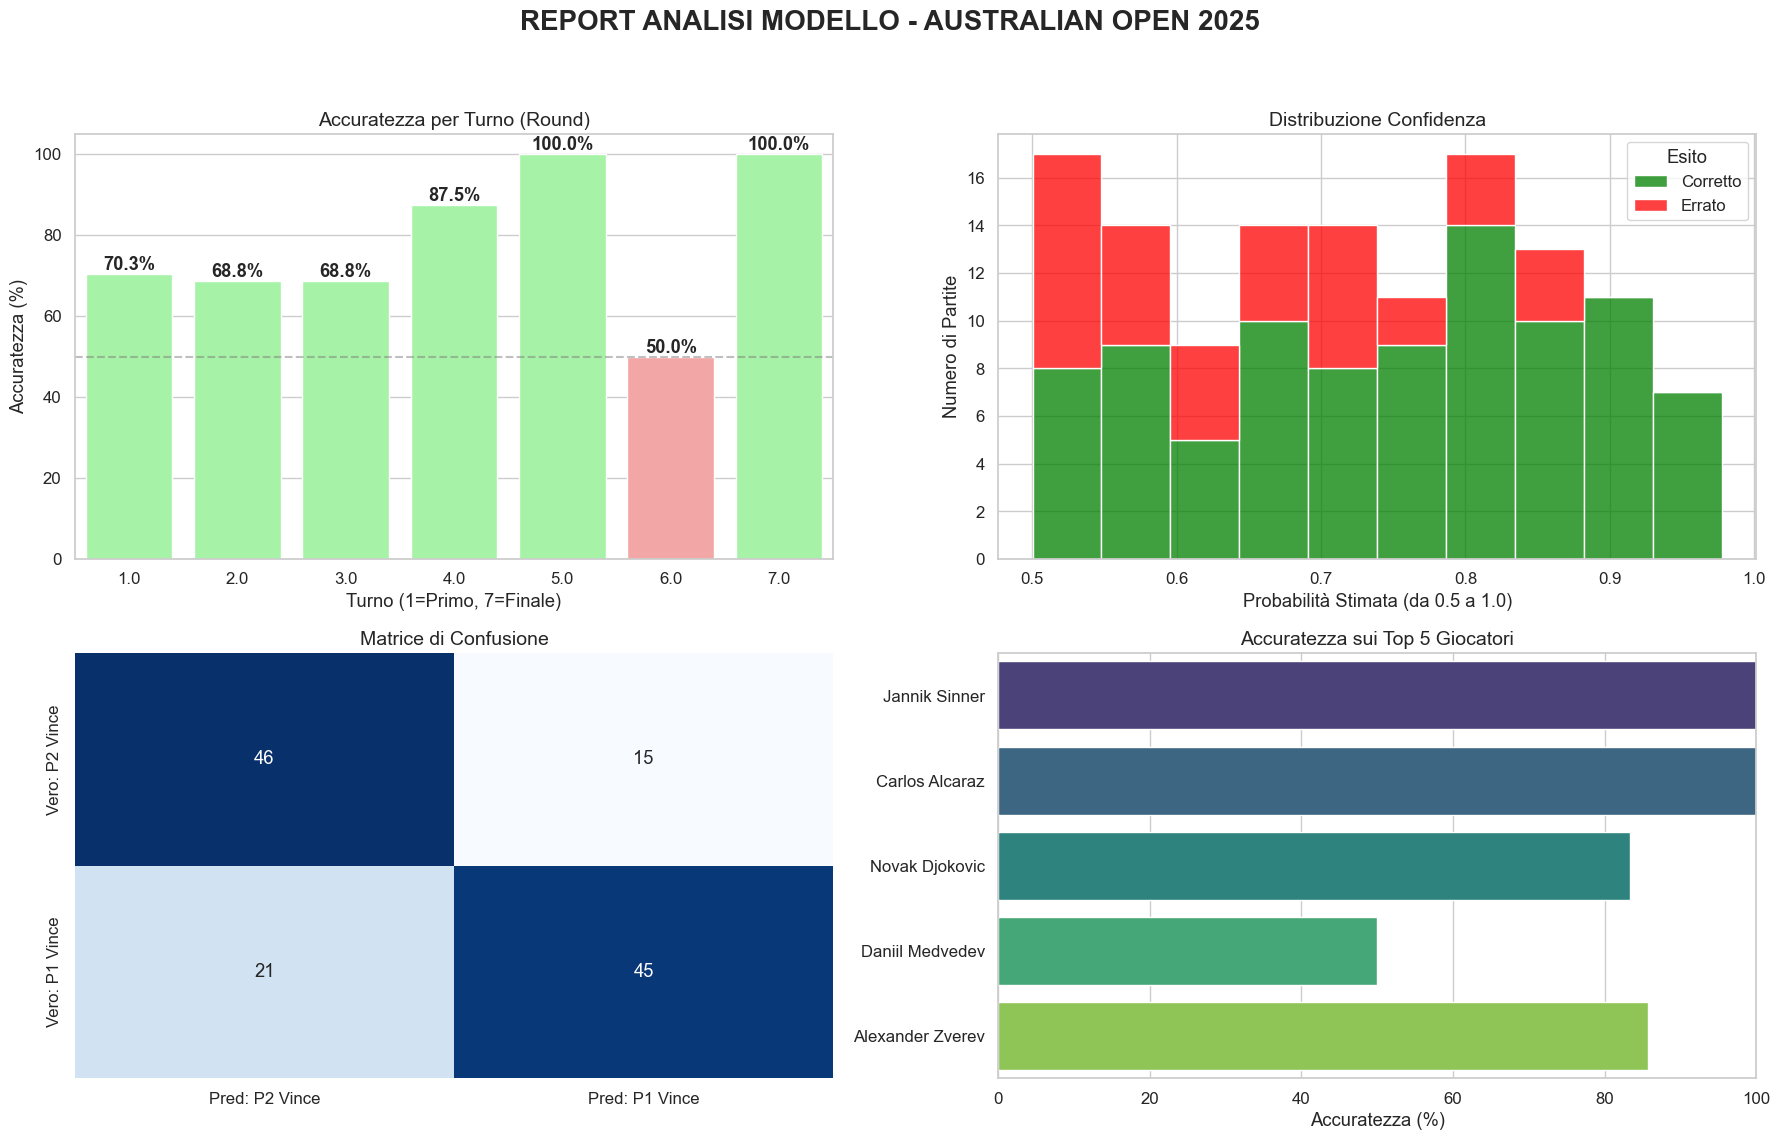


LE SICUREZZE (Match dove il modello era sicuro >90% e ha indovinato)
 round_num              p1_name             p2_name Vincitore_Predetto  Confidenza
       2.0        Jannik Sinner  Tristan Schoolkate      Jannik Sinner    0.977578
       3.0        Jannik Sinner        Marcos Giron      Jannik Sinner    0.969855
       1.0        Jannik Sinner       Nicolas Jarry      Jannik Sinner    0.961367
       3.0       Jacob Fearnley    Alexander Zverev   Alexander Zverev    0.951193
       2.0       Pedro Martinez    Alexander Zverev   Alexander Zverev    0.947119
       6.0        Jannik Sinner         Ben Shelton      Jannik Sinner    0.933132
       1.0       Novak Djokovic Nishesh Basavareddy     Novak Djokovic    0.932923
       1.0 Alexander Shevchenko      Carlos Alcaraz     Carlos Alcaraz    0.925670
       3.0          Nuno Borges      Carlos Alcaraz     Carlos Alcaraz    0.925135
       2.0       Novak Djokovic         Jaime Faria     Novak Djokovic    0.923550
       1.0       

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Caricamento e Preparazione
df = pd.read_csv("datasets_produced\\AO_2025_FULL_RESULTS.csv")

# Creiamo colonne leggibili per gli umani
df['Vincitore_Reale'] = df.apply(lambda x: x['p1_name'] if x['target'] == 1 else x['p2_name'], axis=1)
df['Vincitore_Predetto'] = df.apply(lambda x: x['p1_name'] if x['Model_Prediction'] == 1 else x['p2_name'], axis=1)

# Calcoliamo la "Confidenza" (Quanto il modello era sicuro, da 50% a 100%)
# Se Prob è 0.9 -> Confidenza 0.9. Se Prob è 0.1 -> Confidenza 0.9 (era sicuro che perdesse)
df['Confidenza'] = df['Model_Prob_P1'].apply(lambda x: x if x > 0.5 else 1 - x)

# Impostiamo lo stile grafico
sns.set_style("whitegrid")
plt.figure(figsize=(18, 12))
plt.suptitle("REPORT ANALISI MODELLO - AUSTRALIAN OPEN 2025", fontsize=20, fontweight='bold')

# --- GRAFICO 1: ACCURATEZZA PER TURNO ---
plt.subplot(2, 2, 1)
acc_by_round = df.groupby('round_num')['Correct'].mean() * 100
colors = ['#ff9999' if x < 60 else '#99ff99' for x in acc_by_round] # Rosso se male, Verde se bene
ax1 = sns.barplot(
    x=acc_by_round.index, 
    y=acc_by_round.values, 
    hue=acc_by_round.index,  
    palette=colors, 
    legend=False            
)
plt.title("Accuratezza per Turno (Round)", fontsize=14)
plt.ylabel("Accuratezza (%)")
plt.xlabel("Turno (1=Primo, 7=Finale)")
plt.axhline(50, color='grey', linestyle='--', alpha=0.5) # Linea del 50%
for i, v in enumerate(acc_by_round):
    ax1.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

# --- GRAFICO 2: ISTOGRAMMA DELLA FIDUCIA ---
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='Confidenza', hue='Correct', multiple='stack', bins=10, palette={0: 'red', 1: 'green'})
plt.title("Distribuzione Confidenza", fontsize=14)
plt.xlabel("Probabilità Stimata (da 0.5 a 1.0)")
plt.ylabel("Numero di Partite")
plt.legend(title='Esito', labels=['Corretto', 'Errato'])
# Nota: Più verde c'è a destra, meglio è.

# --- GRAFICO 3: CONFUSION MATRIX ---
plt.subplot(2, 2, 3)
cm = confusion_matrix(df['target'], df['Model_Prediction'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Pred: P2 Vince', 'Pred: P1 Vince'],
            yticklabels=['Vero: P2 Vince', 'Vero: P1 Vince'])
plt.title("Matrice di Confusione", fontsize=14)

# --- GRAFICO 4: TOP PLAYER PERFORMANCE ---
plt.subplot(2, 2, 4)
top_players = ['Jannik Sinner', 'Carlos Alcaraz', 'Novak Djokovic', 'Daniil Medvedev', 'Alexander Zverev']
player_acc = []
for p in top_players:
    matches = df[(df['p1_name'] == p) | (df['p2_name'] == p)]
    acc = matches['Correct'].mean() * 100
    player_acc.append(acc)

sns.barplot(
    x=player_acc, 
    y=top_players, 
    hue=top_players,    
    palette="viridis", 
    legend=False         
)
plt.title("Accuratezza sui Top 5 Giocatori", fontsize=14)
plt.xlabel("Accuratezza (%)")
plt.xlim(0, 100)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==========================================
# REPORT TESTUALE 
# ==========================================

print("\n" + "="*80)
print("LE SICUREZZE (Match dove il modello era sicuro >90% e ha indovinato)")
print("="*80)
safe_bets = df[(df['Confidenza'] > 0.90) & (df['Correct'] == 1)].sort_values('Confidenza', ascending=False)
display_cols = ['round_num', 'p1_name', 'p2_name', 'Vincitore_Predetto', 'Confidenza']
print(safe_bets[display_cols].to_string(index=False))

print("\n" + "="*80)
print("LE DELUSIONI (Match dove il modello era sicuro >75% ma ha sbagliato)")
print("="*80)
upsets = df[(df['Confidenza'] > 0.75) & (df['Correct'] == 0)].sort_values('Confidenza', ascending=False)

print(upsets[display_cols].to_string(index=False))


print("\n" + "="*80)
print("IL CAMMINO DI SINNER")
print("="*80)
sinner_matches = df[(df['p1_name'] == 'Jannik Sinner') | (df['p2_name'] == 'Jannik Sinner')].sort_values('round_num')
for idx, row in sinner_matches.iterrows():
    avversario = row['p2_name'] if row['p1_name'] == 'Jannik Sinner' else row['p1_name']
    esito = "INDOVINATO" if row['Correct'] == 1 else "ERRORE"
    prob = row['Model_Prob_P1'] if row['p1_name'] == 'Jannik Sinner' else (1 - row['Model_Prob_P1'])
    print(f"Round {int(row['round_num'])} vs {avversario:<20} | Modello: {prob:.1%} Sinner | Esito Reale: {row['Vincitore_Reale']:<15} -> {esito}")

In [21]:
# ====================================================
# 1. CARICAMENTO E ADDESTRAMENTO MODELLO 
# ====================================================

df_historical = pd.read_csv("datasets_produced\\dataset_ml_ready.csv") 

features_list = [
    'best_of', 'round_num',
    'surface_Hard', 'surface_Clay', 'surface_Grass', 'surface_Carpet', 
    'diff_age', 'diff_ht', 'p1_is_left', 'p2_is_left', 
    'DIFF_ELO', 'DIFF_SURF_ELO', 'ATP_RANK_DIFF', 'ATP_POINT_DIFF', 
    'DIFF_H2H', 'DIFF_N_GAMES', 
    'WIN_LAST_5_DIFF', 'WIN_LAST_25_DIFF', 'WIN_LAST_50_DIFF', 'WIN_LAST_100_DIFF', 
    'ELO_GRAD_20_DIFF', 'ELO_GRAD_35_DIFF', 'ELO_GRAD_50_DIFF', 'ELO_GRAD_100_DIFF'
]

X_full = df_historical[features_list].fillna(0)
y_full = df_historical['target']

scaler_final = StandardScaler()
X_full_scaled = scaler_final.fit_transform(X_full)

final_model = MLPClassifier(
    hidden_layer_sizes=(128, 128, 64, 32),
    activation='relu', 
    alpha=0.01, 
    max_iter=150, 
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42
)

final_model.fit(X_full_scaled, y_full)

# ========================================
# 2. PREPARAZIONE DATI TORNEO 
# ========================================

# Caricamento Players e Draw
df_players = pd.read_csv("datasets_produced\\players_2025_ready.csv").set_index('player_name')
df_draw = pd.read_csv("datasets_produced\\AO 2025.csv", sep=';')

df_draw['p1_name'] = df_draw['p1_name'].str.strip()
df_draw['p2_name'] = df_draw['p2_name'].str.strip()

missing_profiles = {
    'Tristan Boyer': {
        'elo': 1450, 'hard_elo': 1460, 'rank': 134, 'rank_points': 450, 'age': 23.7, 'ht': 188, 'is_left': 0, 'matches_played': 5, 'win_last_5': 0.4, 'win_last_25': 0.4, 'win_last_50': 0.4, 'win_last_100': 0.4, 'elo_grad_20': 10, 'elo_grad_35': 10, 'elo_grad_50': 10, 'elo_grad_100': 10
    },
    'Gauthier Onclin': {
        'elo': 1410, 'hard_elo': 1410, 'rank': 218, 'rank_points': 280, 'age': 23.9, 'ht': 180, 'is_left': 0, 'matches_played': 2, 'win_last_5': 0.3, 'win_last_25': 0.3, 'win_last_50': 0.3, 'win_last_100': 0.3, 'elo_grad_20': 5, 'elo_grad_35': 5, 'elo_grad_50': 5, 'elo_grad_100': 5
    }
}
for name, stats in missing_profiles.items():
    if name not in df_players.index:
        df_players.loc[name] = pd.Series(stats)

h2h_stats = defaultdict(lambda: defaultdict(int))
for idx, row in df_historical.iterrows():
    w = row['p1_name'] if row['target'] == 1 else row['p2_name']
    l = row['p2_name'] if row['target'] == 1 else row['p1_name']
    h2h_stats[w][l] += 1

# ==============================================================================
# 3. FUNZIONE DI PREDIZIONE SINGOLA (Features -> Scale -> Predict)
# ==============================================================================
def predict_match_mlp(p1_name, p2_name, round_num):
    if p1_name not in df_players.index or p2_name not in df_players.index:
        return p1_name, 0.5 
        
    s1 = df_players.loc[p1_name]
    s2 = df_players.loc[p2_name]
    
    wins_p1 = h2h_stats.get(p1_name, {}).get(p2_name, 0)
    wins_p2 = h2h_stats.get(p2_name, {}).get(p1_name, 0)
    
    match_row = {
        'best_of': 5, 
        'round_num': round_num,
        'surface_Hard': 1, 'surface_Clay': 0, 'surface_Grass': 0, 'surface_Carpet': 0,
        'diff_age': s1['age'] - s2['age'],
        'diff_ht': s1['ht'] - s2['ht'],
        'p1_is_left': s1['is_left'], 'p2_is_left': s2['is_left'],
        'DIFF_ELO': s1['elo'] - s2['elo'],
        'DIFF_SURF_ELO': s1['hard_elo'] - s2['hard_elo'],
        'ATP_RANK_DIFF': s1['rank'] - s2['rank'],
        'ATP_POINT_DIFF': s1['rank_points'] - s2['rank_points'],
        'DIFF_H2H': wins_p1 - wins_p2, 
        'DIFF_N_GAMES': s1['matches_played'] - s2['matches_played'],
        'WIN_LAST_5_DIFF': s1['win_last_5'] - s2['win_last_5'],
        'WIN_LAST_25_DIFF': s1['win_last_25'] - s2['win_last_25'],
        'WIN_LAST_50_DIFF': s1['win_last_50'] - s2['win_last_50'],
        'WIN_LAST_100_DIFF': s1['win_last_100'] - s2['win_last_100'],
        'ELO_GRAD_20_DIFF': s1['elo_grad_20'] - s2['elo_grad_20'],
        'ELO_GRAD_35_DIFF': s1['elo_grad_35'] - s2['elo_grad_35'],
        'ELO_GRAD_50_DIFF': s1['elo_grad_50'] - s2['elo_grad_50'],
        'ELO_GRAD_100_DIFF': s1['elo_grad_100'] - s2['elo_grad_100']
    }
    
    X_match = pd.DataFrame([match_row])[features_list].fillna(0)
    
    X_match_scaled = scaler_final.transform(X_match)
    
    prob_p1 = final_model.predict_proba(X_match_scaled)[0, 1]
    
    if prob_p1 >= 0.5:
        return p1_name, prob_p1
    else:
        return p2_name, 1 - prob_p1

# ==============================================================================
# 4. SIMULAZIONE LOOP TORNEO
# ==============================================================================
print(f"\n{'='*60}\nSIMULAZIONE AUSTRALIAN OPEN 2025 \n{'='*60}")

# Prendiamo i match del primo turno, manteniamo l'ordine del tabellone
current_matches = df_draw[df_draw['round_num'] == 1][['p1_name', 'p2_name']].values.tolist()
round_num = 1
tournament_log = []

while len(current_matches) > 0:
    print(f"\n--- TURNO {round_num} ({len(current_matches)} partite) ---")
    
    next_round_players = []
    
    for p1, p2 in current_matches:
        winner, prob = predict_match_mlp(p1, p2, round_num)
        
        next_round_players.append(winner)
        tournament_log.append({
            'Round': round_num,
            'Player1': p1, 'Player2': p2,
            'Winner': winner, 'Probability': prob
        })
        
        print(f"Match: {p1} vs {p2} -> Vince {winner} ({prob:.1%})")

    if len(next_round_players) == 1:
        print(f"\n{'='*60}")
        print(f"CAMPIONE AUSTRALIAN OPEN 2025: {next_round_players[0].upper()}")
        print(f"{'='*60}")
        break
    
    # Creazione accoppiamenti prossimo turno
    # Regola: Vincitore Match 1 vs Vincitore Match 2, Vincitore Match 3 vs 4...
    new_matches = []
    for i in range(0, len(next_round_players), 2):
        if i + 1 < len(next_round_players):
            new_matches.append([next_round_players[i], next_round_players[i+1]])
        else:
            new_matches.append([next_round_players[i], "BYE"])
            
    current_matches = new_matches
    round_num += 1

# Salvataggio risultati completi
df_sim_results = pd.DataFrame(tournament_log)
df_sim_results.to_csv("datasets_produced\\AO_2025_FULL_SIMULATION.csv", index=False)
print("\nSimulazione salvata in 'AO_2025_FULL_SIMULATION.csv'")


SIMULAZIONE AUSTRALIAN OPEN 2025 

--- TURNO 1 (64 partite) ---
Match: Jannik Sinner vs Nicolas Jarry -> Vince Jannik Sinner (96.1%)
Match: Tristan Schoolkate vs Taro Daniel -> Vince Taro Daniel (50.1%)
Match: Marcos Giron vs Yannick Hanfmann -> Vince Marcos Giron (58.3%)
Match: Tomas Martin Etcheverry vs Flavio Cobolli -> Vince Flavio Cobolli (74.0%)
Match: Hubert Hurkacz vs Tallon Griekspoor -> Vince Hubert Hurkacz (58.9%)
Match: Miomir Kecmanovic vs Dusan Lajovic -> Vince Miomir Kecmanovic (62.5%)
Match: Matteo Berrettini vs Cameron Norrie -> Vince Cameron Norrie (55.3%)
Match: Zhizhen Zhang vs Holger Rune -> Vince Holger Rune (88.7%)
Match: Stefanos Tsitsipas vs Alex Michelsen -> Vince Stefanos Tsitsipas (53.5%)
Match: James Mccabe vs Martin Landaluce -> Vince Martin Landaluce (61.9%)
Match: Gabriel Diallo vs Luca Nardi -> Vince Gabriel Diallo (60.1%)
Match: Adrian Mannarino vs Karen Khachanov -> Vince Karen Khachanov (86.4%)
Match: Francisco Cerundolo vs Alexander Bublik -> Vince

   Turno  Giocatori_Totali  Giocatori_Indovinati  Percentuale
0      1                64                    45      70.3125
1      2                32                    18      56.2500
2      3                16                     9      56.2500
3      4                 8                     6      75.0000
4      5                 4                     3      75.0000
5      6                 2                     1      50.0000
6      7                 1                     1     100.0000


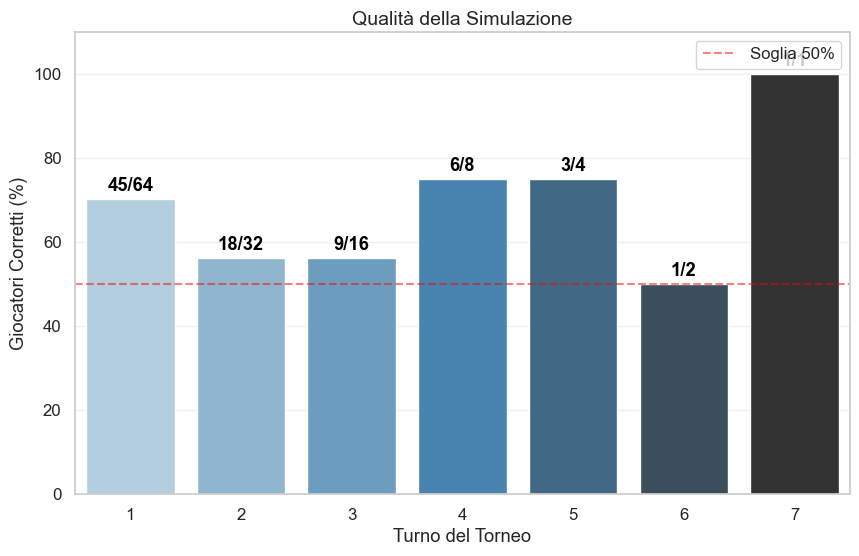

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_sim = pd.read_csv("datasets_produced\\AO_2025_FULL_SIMULATION.csv")
df_real = pd.read_csv("datasets_produced\\AO_2025_FULL_RESULTS.csv")

# Funzione per estrarre i vincitori reali per ogni turno
def get_real_winners_per_round(df):
    winners = {}
    for r in sorted(df['round_num'].unique()):
        # Se target=1 vince P1, se 0 vince P2
        round_matches = df[df['round_num'] == r]
        w_list = round_matches.apply(lambda x: x['p1_name'] if x['target'] == 1 else x['p2_name'], axis=1).tolist()
        winners[int(r)] = set(w_list)
    return winners

# Funzione per estrarre i vincitori simulati
def get_sim_winners_per_round(df):
    winners = {}
    for r in sorted(df['Round'].unique()):
        w_list = df[df['Round'] == r]['Winner'].tolist()
        winners[int(r)] = set(w_list)
    return winners

real_winners = get_real_winners_per_round(df_real)
sim_winners = get_sim_winners_per_round(df_sim)

# Creiamo la tabella di confronto
comparison_data = []
for r in sorted(real_winners.keys()):
    if r in sim_winners:
        real_set = real_winners[r]
        sim_set = sim_winners[r]
        
        # Quanti giocatori sono in comune tra i due set?
        common_players = real_set.intersection(sim_set)
        match_rate = len(common_players) / len(real_set) * 100
        
        comparison_data.append({
            'Turno': r,
            'Giocatori_Totali': len(real_set),
            'Giocatori_Indovinati': len(common_players),
            'Percentuale': match_rate,
            'Nomi_Indovinati': ", ".join(list(common_players)[:3]) + ("..." if len(common_players)>3 else "") 
        })

df_compare = pd.DataFrame(comparison_data)

print(df_compare[['Turno', 'Giocatori_Totali', 'Giocatori_Indovinati', 'Percentuale']])

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df_compare, x='Turno', y='Percentuale', hue='Turno', palette='Blues_d', dodge=False)

if ax.legend_:
    ax.legend_.remove()

plt.title("Qualità della Simulazione", fontsize=14)
plt.ylabel("Giocatori Corretti (%)")
plt.xlabel("Turno del Torneo")


line = plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='Soglia 50%')
plt.ylim(0, 110)

for index, row in df_compare.iterrows():
    plt.text(row.name, row.Percentuale + 2, f"{int(row.Giocatori_Indovinati)}/{row.Giocatori_Totali}", 
             color='black', ha="center", fontweight='bold')

plt.legend(handles=[line], loc='upper right')

plt.grid(axis='y', alpha=0.3)
plt.show()